# Instalare dependente si descarcare date


In [1]:
!pip install networkx matplotlib numpy -q

In [36]:
import os
import glob

url_corect = 'https://github.com/lauradiosan/AI-UBB/raw/main/2025-2026/labs/lab11/real-networks.zip'

if not os.path.exists('real-networks.zip'):
    !wget -q {url_corect} -O real-networks.zip

!unzip -o -q real-networks.zip

print('Fisierele GML gasite:')
gml_files = glob.glob('real/**/*.gml', recursive=True)

if not gml_files:
    print('Nu s-a găsit niciun fisier .gml!')
else:
    for f in sorted(gml_files):
        print(' ', f)

Fisierele GML gasite:
  real/dolphins/dolphins.gml
  real/football/football.gml
  real/karate/karate.gml
  real/krebs/krebs.gml


# Importuri si configurare

In [3]:
import networkx as nx
import networkx.algorithms.community as nx_comm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import random
import re
import time
import os
from copy import deepcopy
from collections import defaultdict

random.seed(42)
np.random.seed(42)

# Incarcarea datelor (GML + classLabel)

In [4]:
def load_gml_safe(path):
    """
    Citeste un fisier GML ignorand muchiile duplicate.
    Returneaza un NetworkX Graph simplu, neorientat, 0-indexat.
    """
    for label in ('id', 'label', None):
        try:
            kwargs = {'label': label} if label else {}
            G = nx.read_gml(path, **kwargs)
            break
        except Exception:
            G = None

    if G is None:
        with open(path, 'r', encoding='utf-8', errors='ignore') as f:
            content = f.read()
        node_ids = re.findall(r'node\s*\[.*?id\s+(\d+).*?\]', content, re.DOTALL)
        if not node_ids:
            node_ids = re.findall(r'id\s+(\d+)', content)
        edge_pairs = re.findall(r'source\s+(\d+)\s+target\s+(\d+)', content)
        G = nx.Graph()
        G.add_nodes_from(int(n) for n in node_ids)
        G.add_edges_from((int(s), int(t)) for s, t in edge_pairs)

    G = nx.Graph(G)
    G.remove_edges_from(nx.selfloop_edges(G))
    G = G.to_undirected()

    mapping = {old: new for new, old in enumerate(sorted(G.nodes()))}
    G = nx.relabel_nodes(G, mapping)

    n = G.number_of_nodes()
    m = G.number_of_edges()
    deg = dict(G.degree())

    net = {
        'G'       : G,
        'noNodes' : n,
        'noEdges' : m,
        'mat'     : nx.to_numpy_array(G, dtype=np.int8),
        'degrees' : [deg[i] for i in range(n)],
        'name'    : os.path.splitext(os.path.basename(path))[0]
    }
    return net

In [5]:
def load_ground_truth(label_path, net):
    """
    Citeste fisierul classLabel adaptat la nodurile deja indexate din structura 'net'.
    """
    n_nodes = net['noNodes']
    G = net['G']

    gt_dict = {}

    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 2:
                    try:
                        old_node_id = int(parts[0])
                        comm = int(parts[1])
                        gt_dict[old_node_id] = comm
                    except ValueError:
                        continue

    unique_communities = sorted(list(set(gt_dict.values())))
    remap_comm = {old: new for new, old in enumerate(unique_communities)}

    gt_labels = []

    default_comm_mapped = 0

    for i in range(n_nodes):
        possible_old_id = i + 1

        if possible_old_id in gt_dict:
            old_comm = gt_dict[possible_old_id]
            gt_labels.append(remap_comm[old_comm])
        else:
            if i in gt_dict:
                old_comm = gt_dict[i]
                gt_labels.append(remap_comm[old_comm])
            else:
                gt_labels.append(default_comm_mapped)

    return gt_labels

In [32]:
def load_networkx_builtin(name):
    """
    Incarca una dintre retelele incluse in networkx (pentru retelele proprii).
    Suporta atat retelele de baza, cat si cele doua variante avansate si reale.
    """
    import networkx as nx
    import numpy as np

    if name == 'les_miserables':
        G = nx.les_miserables_graph()
    elif name == 'davis_women':
        G = nx.davis_southern_women_graph()
    elif name == 'florentine':
        G = nx.florentine_families_graph()
    elif name == 'petersen':
        G = nx.petersen_graph()

    elif name == 'florentine_dense':
        G = nx.florentine_families_graph()
        extra_edges = [('Strozzi', 'Guadagni'), ('Medici', 'Albizzi'), ('Peruzzi', 'Castellani')]
        for u, v in extra_edges:
            if G.has_node(u) and G.has_node(v):
                G.add_edge(u, v)

    elif name == 'davis_projected':
        B = nx.davis_southern_women_graph()
        women = [n for n, d in B.nodes(data=True) if d.get('bipartite') == 0]
        G = nx.bipartite.projected_graph(B, women)
    else:
        raise KeyError(f"Reteaua '{name}' nu este definita in load_networkx_builtin.")

    G = nx.Graph(G)
    mapping = {old: new for new, old in enumerate(sorted(G.nodes()))}
    G = nx.relabel_nodes(G, mapping)
    G.remove_edges_from(nx.selfloop_edges(G))

    n   = G.number_of_nodes()
    m   = G.number_of_edges()
    deg = dict(G.degree())

    return {
        'G'       : G,
        'noNodes' : n,
        'noEdges' : m,
        'mat'     : nx.to_numpy_array(G, dtype=np.int32),
        'degrees' : [deg[i] for i in range(n)],
        'name'    : name
    }

# Functiile de fitness

In [7]:
# Functia fitness de modularitate
def modularity(communities, net):
    """
    Calculeaza modularitatea Q pentru o impartire pe comunitati.

    Formula: Q = (1/2m) * Σ_{i,j} [A_ij - k_i*k_j/(2m)] * δ(c_i, c_j)

    Unde:
      A_ij = 1 dacă există muchie între i și j
      k_i = gradul nodului i
      2m = suma tuturor gradelor
      δ(c_i,c_j) = 1 dacă i,j sunt în aceeași comunitate

    Returneaza Q ∈ [-1, 1]; valori mai mari = comunitati mai bune.
    """
    M = 2 * net['noEdges']
    if M == 0:
        return 0.0
    mat = net['mat']
    degrees = net['degrees']
    n = net['noNodes']
    Q = 0.0
    for i in range(n):
        for j in range(n):
            if communities[i] == communities[j]:
                Q += mat[i][j] - degrees[i] * degrees[j] / M
    return Q / M

In [8]:
# Functia de conductanta

def conductance_fitness(communities, net):
    """
    Fitness bazat pe conductanta medie

    Conductance(S) = cut(S, V / S) / min(vol(S), vol(V / S))
    unde:
      cut(S, V / S) = numarul de muchii care traverseaza frontiera comunitatii
      vol(S) = suma gradelor nodurilor din S

    Valori mici de conductanta = comunitati bine separate.
    Returnam negatul pentru ca algoritmul maximizeaza.
    """
    G = net['G']
    n = net['noNodes']
    degrees = net['degrees']

    comm_sets = defaultdict(set)
    for node, cid in enumerate(communities):
        comm_sets[cid].add(node)

    if len(comm_sets) <= 1:
        return -1.0

    conductances = []
    for members in comm_sets.values():
        if len(members) == 0 or len(members) == n:
            continue
        cut    = sum(1 for u in members
                       for v in G.neighbors(u) if v not in members)
        vol_s  = sum(degrees[u] for u in members)
        vol_c  = sum(degrees[u] for u in range(n) if u not in members)
        denom  = min(vol_s, vol_c)
        if denom > 0:
            conductances.append(cut / denom)

    return -np.mean(conductances) if conductances else -1.0

In [9]:
# Functia de fitness Coverage
def coverage_fitness(communities, net):
    """
    Fitness bazat pe coverage (acoperire interna).

    Coverage = (muchii interne) / (total muchii)

    Masoara ce fractie din muchii se afla inauntrul comunitatilor.
    O valoare ridicata inseamna ca majoritatea conexiunilor sunt
    in interiorul grupurilor, deci comunitati bine definite.
    Returnează valori în [0, 1]; mai mare = mai bine.
    Ref: Lancichinetti & Fortunato (2009)
    """
    mat = net['mat']
    n   = net['noNodes']
    m   = net['noEdges']
    if m == 0:
        return 0.0

    internal = 0
    for i in range(n):
        for j in range(i + 1, n):
            if communities[i] == communities[j] and mat[i][j] == 1:
                internal += 1
    return internal / m

In [10]:
FITNESS_FUNCTIONS = {
    'modularity'  : modularity,
    'conductance' : conductance_fitness,
    'coverage'    : coverage_fitness,
}

_net = load_gml_safe('real/karate/karate.gml')
_gt  = load_ground_truth('real/karate/classLabelkarate.txt', _net)

print(f'Karate ground-truth → Q={modularity(_gt, _net):.4f}, '
      f'Cond={conductance_fitness(_gt, _net):.4f}, '
      f'Coverage={coverage_fitness(_gt, _net):.4f}')

Karate ground-truth → Q=0.3715, Cond=-0.1316, Coverage=0.8718


# Cromozomul si operatorii generici

In [11]:
class Chromosome:
    """
    Reprezentare: vector de intregi de lungime N (numar noduri).
    repres[i] = ID-ul comunitatii nodului i, valori in [0, maxComm-1].

    """

    def __init__(self, n_nodes, max_comm):
        self.n_nodes  = n_nodes
        self.max_comm = max_comm
        # Inițializare aleatorie: fiecare nod are la inceput o comunitate random
        self.repres   = [random.randint(0, max_comm - 1) for _ in range(n_nodes)]
        self.fitness  = None
        self._normalize()

    def _normalize(self):
        # Aici se rescriu etichetele in ordinea gasirii lor,
        # intrucat se poate intampla sa se gaseasca aceleasi comunitati cu denumiri diferite
        seen, new_id, new_repres = {}, 0, []
        for cid in self.repres:
            if cid not in seen:
                seen[cid] = new_id
                new_id   += 1
            new_repres.append(seen[cid])
        self.repres = new_repres

    def crossover(self, other):
        # Incrucisare one-point:
        #  - se alege aleator un punct de taiere
        #  - copilul preia stanga de la parintele 1, dreapta de la parintele 2

        # P1: [1,1,2,2 | 3,3,1,0]
        # P2: [2,0,2,1 | 1,2,2,1]
        # → C: [1,1,2,2,  1,2,2,1]
        child = Chromosome.__new__(Chromosome)
        child.n_nodes  = self.n_nodes
        child.max_comm = self.max_comm
        child.fitness  = None
        cut            = random.randint(1, self.n_nodes - 1)
        child.repres   = self.repres[:cut] + other.repres[cut:]
        child._normalize()
        return child

    def crossover_uniform(self, other):
        # Inscrucisare uniforma: fiecare gena vine cu p=0.5 de la P1 sau P2.
        # Produce mai multa diversitate decat one-point.

        child = Chromosome.__new__(Chromosome)
        child.n_nodes  = self.n_nodes
        child.max_comm = self.max_comm
        child.fitness  = None
        child.repres   = [
            self.repres[i] if random.random() < 0.5 else other.repres[i]
            for i in range(self.n_nodes)
        ]
        child._normalize()
        return child

    def mutate(self, pm):
        # Mutatie per-gena: fiecare nod are probabilitatea de a-si schimba comunitatea cu una aleatorie.
        # probabilitatea este mica (0.01-0.05) = explorare controlata.
        # Importanta: Daca la un moment dat toti indivizii din populatie au decis ca nodul 5 apartine comunitatii 1, prin crossover nu ai mai putea schimba asta niciodata.
        # Mutatia este singura care poate "trezi" reteaua, trimitand aleatoriu nodul 5 in comunitatea 3 ca sa vada daca nu cumva fitness-ul (modularitatea) creste.
        changed = False

        for i in range(self.n_nodes):
            if random.random() < pm:
                self.repres[i] = random.randint(0, self.max_comm - 1)
                changed = True
        if changed:
            self._normalize()

    @property
    def n_communities(self):
        return len(set(self.repres))

    def __repr__(self):
        fit_str = f'{self.fitness:.4f}' if self.fitness is not None else 'None'
        return f'Chromosome(comms={self.n_communities}, fitness={fit_str})'

In [12]:
c1 = Chromosome(8, 4)
c2 = Chromosome(8, 4)
copil = c1.crossover(c2)
copil.mutate(0.3)
print(f'P1: {c1.repres}')
print(f'P2: {c2.repres}')
print(f'Copil dupa crossover + mutatie: {copil.repres}')

P1: [0, 0, 1, 2, 2, 2, 0, 0]
P2: [0, 1, 1, 1, 2, 2, 1, 2]
Copil dupa crossover + mutatie: [0, 0, 1, 1, 2, 1, 2, 1]


# Algoritm genetic

In [13]:
class GeneticAlgorithm:
    """
    Algoritm genetic pentru detectia comunitatilor.

    Schema evolutiva: generationala cu elitism optional.
    Selectie: turneu binar.
    Crossover: one-point sau uniform.
    Multatie: per-genă cu probabilitate pm.

    Parametri:
        pop_size   : dimensiunea populației
        no_gen     : numarul de generatii
        pm         : probabilitatea de mutatie per gena
        max_comm   : numarul maxim de comunitati posibile
        fitness_fn : 'modularity' | 'conductance' | 'coverage'
        elitism    : daca e True, cel mai bun individ se pastreaza
        crossover  : 'one_point' | 'uniform'
        verbose    : afiseaza progres la fiecare N generatii (0=silentios)
    """

    def __init__(self, net, pop_size=50, no_gen=150, pm=0.02,
                 max_comm=None, fitness_fn='modularity',
                 elitism=True, crossover='one_point', verbose=0):
        self.net = net
        self.pop_size = pop_size
        self.no_gen = no_gen
        self.pm = pm
        self.max_comm = max_comm or max(2, net['noNodes'] // 3)
        self.fitness_fn = fitness_fn
        self.elitism = elitism
        self.crossover = crossover
        self.verbose = verbose

        self._fit_func = FITNESS_FUNCTIONS[fitness_fn]
        self.population  = []
        self.best_history = []
        self.avg_history  = []

    def _evaluate(self, chrom):
        chrom.fitness = self._fit_func(chrom.repres, self.net)

    def _tournament(self):
        # Alege aleator 2 indivizi din populatie si il returneaza pe cel cu fitness mai mare.
        # Avantaj fata de selectia ruletei: nu e afectat de scala absoluta a fitness-ului.

        a = self.population[random.randint(0, self.pop_size - 1)]
        b = self.population[random.randint(0, self.pop_size - 1)]
        return a if a.fitness >= b.fitness else b

    def _best(self):
        # Functie de sortare si identificare a liderului
        return max(self.population, key=lambda c: c.fitness)

    def _initialize(self):
        # Se initializeaza cu o lista de cromozomi alesi random, practic aceasta reprezentand populatia
        self.population = [
            Chromosome(self.net['noNodes'], self.max_comm)
            for _ in range(self.pop_size)
        ]
        for c in self.population:
            self._evaluate(c)

    def _one_generation(self):
        new_pop = []

        # Elitism: daca este initializat cu valoarea True, atunci cel mai bun supravietuieste garantat
        if self.elitism:
            new_pop.append(deepcopy(self._best()))

        # Generare copii pana umplem populatia
        while len(new_pop) < self.pop_size:
            p1 = self._tournament() # se extrag doi parinti
            p2 = self._tournament()
            child = (p1.crossover(p2)
                     if self.crossover == 'one_point'
                     else p1.crossover_uniform(p2)) # acestia fac un copil
            child.mutate(self.pm) # se aplica mutatia
            self._evaluate(child) # este evaluat
            new_pop.append(child) # este adaugat in lista noii populatii

        self.population = new_pop

    def run(self):
        # Apelarea fiecarei generatii de un numar de ori si raportarea rezultatelor obtinute
        self._initialize()
        start = time.time()

        for gen in range(self.no_gen):
            self._one_generation()

            best_fit = self._best().fitness
            avg_fit  = float(np.mean([c.fitness for c in self.population]))
            self.best_history.append(best_fit)
            self.avg_history.append(avg_fit)

            if self.verbose and (gen + 1) % self.verbose == 0:
                print(f'Gen {gen+1:4d}/{self.no_gen} | '
                      f'Best {self.fitness_fn}: {best_fit:.4f} | '
                      f'Avg: {avg_fit:.4f} | '
                      f'Comunitati: {self._best().n_communities} | '
                      f'Timp: {time.time()-start:.1f}s')

        return self._best()

# Algoritm predefinit din bibliotecă (networkx)

In [14]:
def run_library(net, algorithm='greedy'):
    # Ruleaza un algoritm predefinit din Networkx.
    # Algorithm:
    #  'greedy'  — Greedy Modularity - functioneaza prin mutarea repetata a nodurilor dintr-o comunitate in alta pentru a maximiza Modularitatea,
    #                                  apoi strange comunitatile in super-noduri si repeta procesul.
    #
    #  'louvain' — Louvain method - porneste de la ideea ca fiecare nod este propria sa comunitate individuala, apoi folosind greedy uneste pas cu pas cele doua comunitati
    #                               care aduc cea mai mare creștere a modularitatii, pana cand scorul nu mai poate fi imbunatatit
    #  'label'   — Label Propagation

    # Returneaza un vector de lungime N cu ID-urile din comunitate.

    G = net['G']

    if algorithm == 'louvain':
        comms = nx_comm.louvain_communities(G, seed=42)
    elif algorithm == 'label':
        comms = nx_comm.label_propagation_communities(G)
    else:  # greedy
        comms = nx_comm.greedy_modularity_communities(G)

    node_comm = [0] * net['noNodes']
    for cid, members in enumerate(comms):
        for node in members:
            node_comm[node] = cid
    return node_comm

# Vizualizare

In [15]:
def plot_communities(net, communities, title, ax=None):
    # Deseneaza graful cu nodurile colorate pe comunitati
    G = net['G']
    show = ax is None
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 6))

    pos = nx.spring_layout(G, seed=42)
    unique_comms = sorted(set(communities))
    cmap = plt.colormaps.get_cmap('tab20')
    color_map = {c: cmap(i) for i, c in enumerate(unique_comms)}
    colors = [color_map[communities[n]] for n in sorted(G.nodes())]

    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=120, ax=ax)
    nx.draw_networkx_edges(G, pos, alpha=0.25, ax=ax)
    if net['noNodes'] <= 50:
        nx.draw_networkx_labels(G, pos, font_size=7, ax=ax)
    ax.set_title(title, fontsize=10, pad=6)
    ax.axis('off')

    handles = [mpatches.Patch(color=color_map[c], label=f'C{c}')
               for c in unique_comms]
    ax.legend(handles=handles, loc='upper left', fontsize=6,
              ncol=max(1, len(unique_comms)//6))

In [16]:
def plot_convergence(best_hist, avg_hist, fitness_name, ax=None):
    # Grafic convergenta: best și average fitness pe generatii
    show = ax is None
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 4))

    gens = list(range(1, len(best_hist) + 1))
    ax.plot(gens, best_hist, 'r-',  lw=1.5, label='Best')
    ax.plot(gens, avg_hist,  'b--', lw=1,   label='Average', alpha=0.7)
    ax.set_xlabel('Generatie')
    ax.set_ylabel(fitness_name)
    ax.set_title(f'Convergenta — {fitness_name}', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)

In [17]:
GA_PARAMS = {
    'karate'          : dict(pop_size=60,  no_gen=200, pm=0.03, max_comm=6),
    'dolphins'        : dict(pop_size=60,  no_gen=200, pm=0.02, max_comm=8),
    'football'        : dict(pop_size=80,  no_gen=300, pm=0.02, max_comm=15),
    'krebs'           : dict(pop_size=70,  no_gen=250, pm=0.02, max_comm=10),

    'les_miserables'  : dict(pop_size=60,  no_gen=200, pm=0.02, max_comm=10),
    'davis_women'     : dict(pop_size=50,  no_gen=150, pm=0.03, max_comm=6),
    'florentine'      : dict(pop_size=50,  no_gen=150, pm=0.03, max_comm=6),
    'petersen'        : dict(pop_size=50,  no_gen=100, pm=0.05, max_comm=4),

    'florentine_dense': dict(pop_size=60,  no_gen=150, pm=0.03, max_comm=6),
    'davis_projected' : dict(pop_size=70,  no_gen=200, pm=0.02, max_comm=5),
}

FITNESS_TO_RUN = ['modularity', 'conductance', 'coverage']

In [18]:
def run_experiment(net, gt_labels=None, ga_params=None,
                   fitness_fns=None, verbose=True):
    # Rulează library + GA (cu toate functiile fitness) pe o retea.
    #
    # Intrari:
    #    net        : dicționar de retea
    #    gt_labels  : vector ground truth
    #    ga_params  : dict cu hyperparametrii GA
    #    fitness_fns: lista de functii fitness de rulat
    #    verbose    : dacă True, afiseaza progresul
    #
    # Iesiri:
    #    results    : dict cu toate rezultatele
    #    fig        : figura matplotlib

    name        = net['name']
    ga_params   = ga_params or dict(pop_size=50, no_gen=150, pm=0.02)
    fitness_fns = fitness_fns or ['modularity']
    n_rows      = 1 + len(fitness_fns)  # ground-truth/library + un rand per fitness

    print(f'\n{"="*65}')
    print(f'  Retea: {name.upper()}')
    print(f'  Noduri: {net["noNodes"]} | Muchii: {net["noEdges"]}')
    if gt_labels:
        print(f'  Comunitati reale: {len(set(gt_labels))}')
    print(f'{"="*65}')

    results = {}
    fig, axes = plt.subplots(n_rows, 3, figsize=(18, 5 * n_rows))
    fig.suptitle(f'Community Detection — {name}', fontsize=13, y=1.01)
    if n_rows == 1:
        axes = [axes]


    if gt_labels:
        plot_communities(net, gt_labels,
                         f'Ground truth ({len(set(gt_labels))} comunitati)',
                         ax=axes[0][0])
    else:
        axes[0][0].set_title('(fara ground truth)', fontsize=9)
        axes[0][0].axis('off')

    if verbose:
        print('\n[Library] Greedy Modularity...')
    t0 = time.time()
    lib_comm = run_library(net, 'greedy')
    lib_time = time.time() - t0
    lib_q = modularity(lib_comm, net)
    lib_cov = coverage_fitness(lib_comm, net)
    lib_cond = conductance_fitness(lib_comm, net)
    n_lib = len(set(lib_comm))
    results['library'] = dict(communities=lib_comm, n_communities=n_lib,
                               modularity=lib_q, conductance=lib_cond,
                               coverage=lib_cov, time=lib_time)
    if verbose:
        print(f'Comunitati={n_lib} | Q={lib_q:.4f} | '
              f'Cond={lib_cond:.4f} | Cov={lib_cov:.4f} | '
              f'Timp={lib_time:.3f}s')
    plot_communities(net, lib_comm,
                     f'Library Greedy ({n_lib} comunitati, Q={lib_q:.3f})',
                     ax=axes[0][1])
    axes[0][2].axis('off')

    for row, fit_fn in enumerate(fitness_fns, start=1):
        if verbose:
            print(f'\n[GA / {fit_fn}] pop={ga_params["pop_size"]} '
                  f'gen={ga_params["no_gen"]} pm={ga_params["pm"]}')

        ga = GeneticAlgorithm(
            net,
            pop_size   = ga_params['pop_size'],
            no_gen     = ga_params['no_gen'],
            pm         = ga_params['pm'],
            max_comm   = ga_params.get('max_comm', net['noNodes'] // 3),
            fitness_fn = fit_fn,
            elitism    = True,
            verbose    = ga_params.get('no_gen', 150) // 5 if verbose else 0
        )
        t0   = time.time()
        best = ga.run()
        ga_time = time.time() - t0

        ga_q    = modularity(best.repres, net)
        ga_cond = conductance_fitness(best.repres, net)
        ga_cov  = coverage_fitness(best.repres, net)
        n_ga    = best.n_communities

        results[f'ga_{fit_fn}'] = dict(
            communities=best.repres, n_communities=n_ga,
            modularity=ga_q, conductance=ga_cond,
            coverage=ga_cov, time=ga_time,
            best_history=ga.best_history, avg_history=ga.avg_history
        )
        if verbose:
            print(f'  Comunitati={n_ga} | Q={ga_q:.4f} | '
                  f'Cond={ga_cond:.4f} | Cov={ga_cov:.4f} | '
                  f'Timp={ga_time:.1f}s')

        plot_communities(net, best.repres,
                         f'GA/{fit_fn} ({n_ga} comunitati, Q={ga_q:.3f})',
                         ax=axes[row][0])
        plot_convergence(ga.best_history, ga.avg_history, fit_fn,
                         ax=axes[row][1])

        axes[row][2].axis('off')
        comm_text = (f'Nr. comunitati: {n_ga}\n\n'
                     f'Apartenta noduri:\n'
                     + '\n'.join(
                         f'  Nod {i}: Comunitatea {best.repres[i]}'
                         for i in range(min(15, net['noNodes']))
                     )
                     + (f'\n  ... (+{net["noNodes"]-15} noduri)'
                        if net['noNodes'] > 15 else '')
                    )
        axes[row][2].text(0.02, 0.98, comm_text,
                          transform=axes[row][2].transAxes,
                          va='top', fontsize=8, family='monospace')

    plt.tight_layout()
    plt.show()
    return results, fig

# RETELE DIN ARHIVA

# Retea 1 — Club Karate (34 noduri, 78 muchii)


  Retea: KARATE
  Noduri: 34 | Muchii: 78
  Comunitati reale: 2

[Library] Greedy Modularity...
Comunitati=3 | Q=0.3807 | Cond=-0.2808 | Cov=0.7564 | Timp=0.011s

[GA / modularity] pop=60 gen=200 pm=0.03
Gen   40/200 | Best modularity: 0.2813 | Avg: 0.2111 | Comunitati: 6 | Timp: 4.7s
Gen   80/200 | Best modularity: 0.3562 | Avg: 0.2505 | Comunitati: 5 | Timp: 9.0s
Gen  120/200 | Best modularity: 0.4121 | Avg: 0.2795 | Comunitati: 5 | Timp: 10.9s
Gen  160/200 | Best modularity: 0.4121 | Avg: 0.3135 | Comunitati: 5 | Timp: 13.5s
Gen  200/200 | Best modularity: 0.4121 | Avg: 0.3187 | Comunitati: 5 | Timp: 16.1s
  Comunitati=5 | Q=0.4121 | Cond=-0.4324 | Cov=0.7179 | Timp=16.2s

[GA / conductance] pop=60 gen=200 pm=0.03
Gen   40/200 | Best conductance: -0.5546 | Avg: -0.6189 | Comunitati: 6 | Timp: 0.2s
Gen   80/200 | Best conductance: -0.5152 | Avg: -0.5970 | Comunitati: 6 | Timp: 0.4s
Gen  120/200 | Best conductance: -0.4774 | Avg: -0.5827 | Comunitati: 6 | Timp: 0.5s
Gen  160/200 | Be

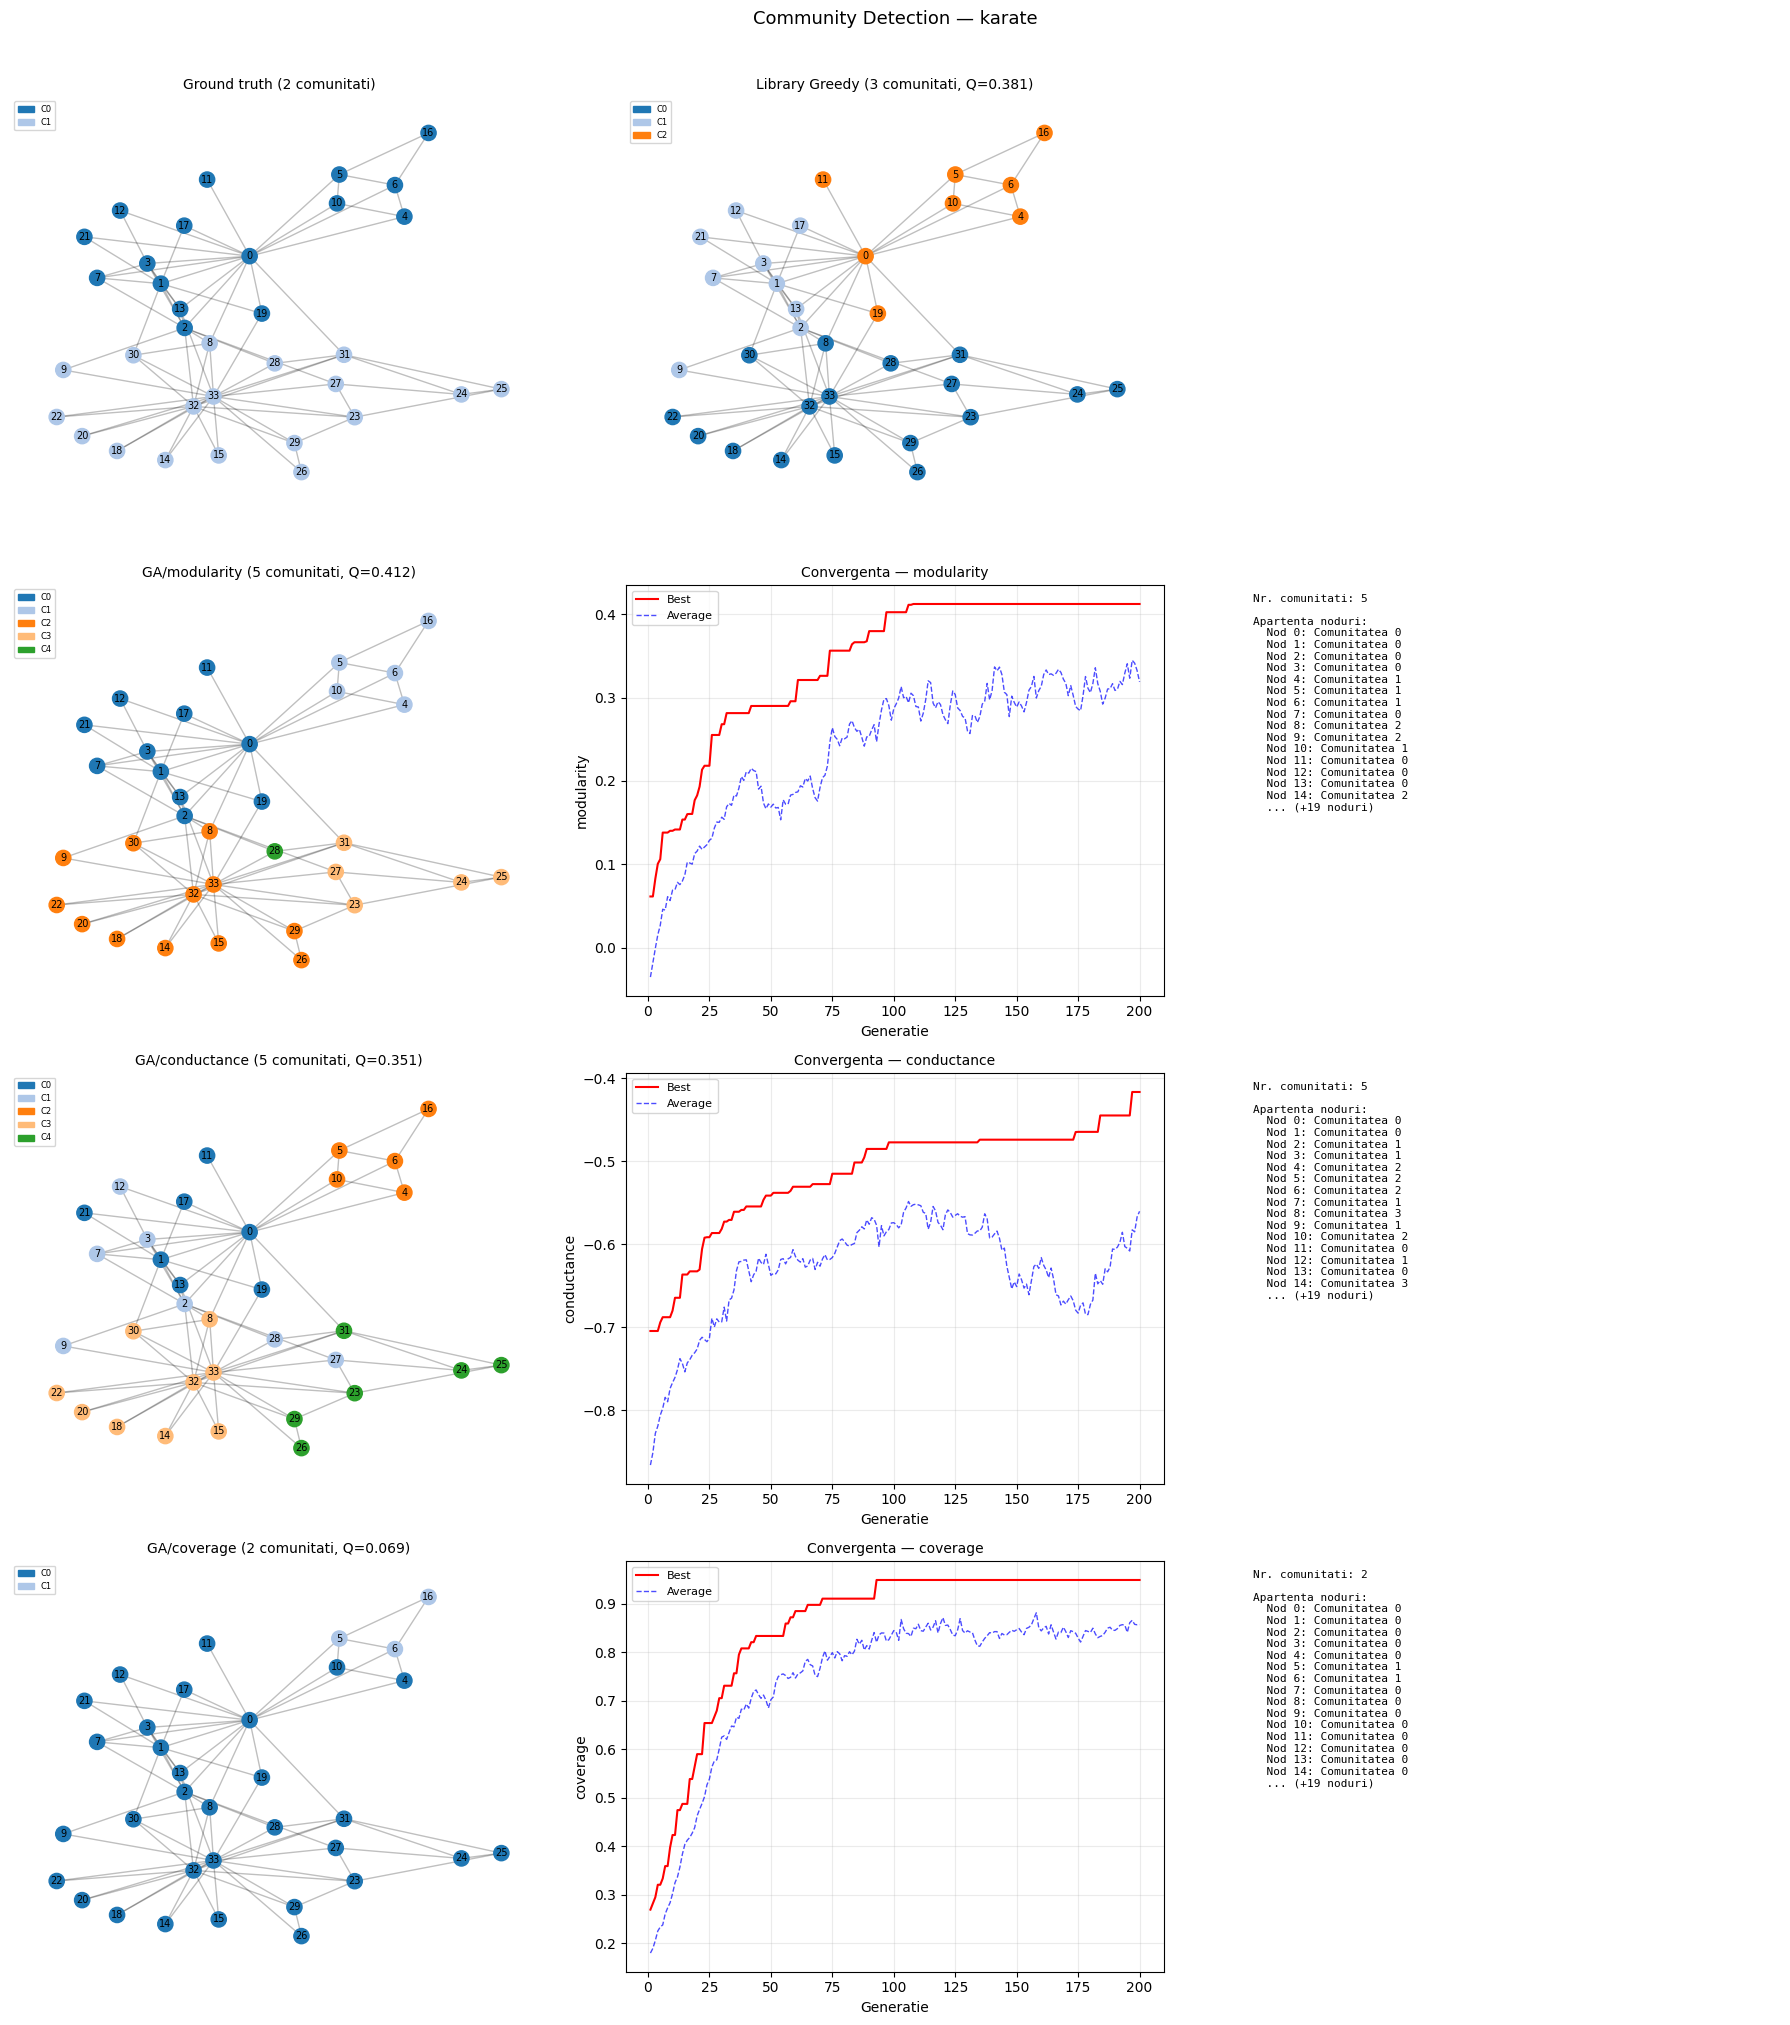

In [19]:
net_karate = load_gml_safe('real/karate/karate.gml')

gt_karate = load_ground_truth('real/karate/classLabelkarate.txt', net_karate)

res_karate, fig_karate = run_experiment(
    net_karate,
    gt_labels   = gt_karate,
    ga_params   = GA_PARAMS['karate'],
    fitness_fns = FITNESS_TO_RUN,
    verbose     = True
)

# Retea 2 — Dolphins (62 noduri, 159 muchii)


  Retea: DOLPHINS
  Noduri: 62 | Muchii: 159
  Comunitati reale: 2

[Library] Greedy Modularity...
Comunitati=4 | Q=0.4955 | Cond=-0.3163 | Cov=0.8239 | Timp=0.008s

[GA / modularity] pop=60 gen=200 pm=0.02
Gen   40/200 | Best modularity: 0.2202 | Avg: 0.1465 | Comunitati: 8 | Timp: 3.6s
Gen   80/200 | Best modularity: 0.3194 | Avg: 0.2364 | Comunitati: 8 | Timp: 8.8s
Gen  120/200 | Best modularity: 0.3837 | Avg: 0.2706 | Comunitati: 7 | Timp: 12.6s
Gen  160/200 | Best modularity: 0.3972 | Avg: 0.3061 | Comunitati: 7 | Timp: 16.6s
Gen  200/200 | Best modularity: 0.4181 | Avg: 0.3483 | Comunitati: 8 | Timp: 22.1s
  Comunitati=8 | Q=0.4181 | Cond=-0.5309 | Cov=0.5912 | Timp=22.1s

[GA / conductance] pop=60 gen=200 pm=0.02
Gen   40/200 | Best conductance: -0.6978 | Avg: -0.7577 | Comunitati: 8 | Timp: 0.3s
Gen   80/200 | Best conductance: -0.6246 | Avg: -0.7039 | Comunitati: 7 | Timp: 0.6s
Gen  120/200 | Best conductance: -0.5738 | Avg: -0.6601 | Comunitati: 7 | Timp: 1.0s
Gen  160/200 |

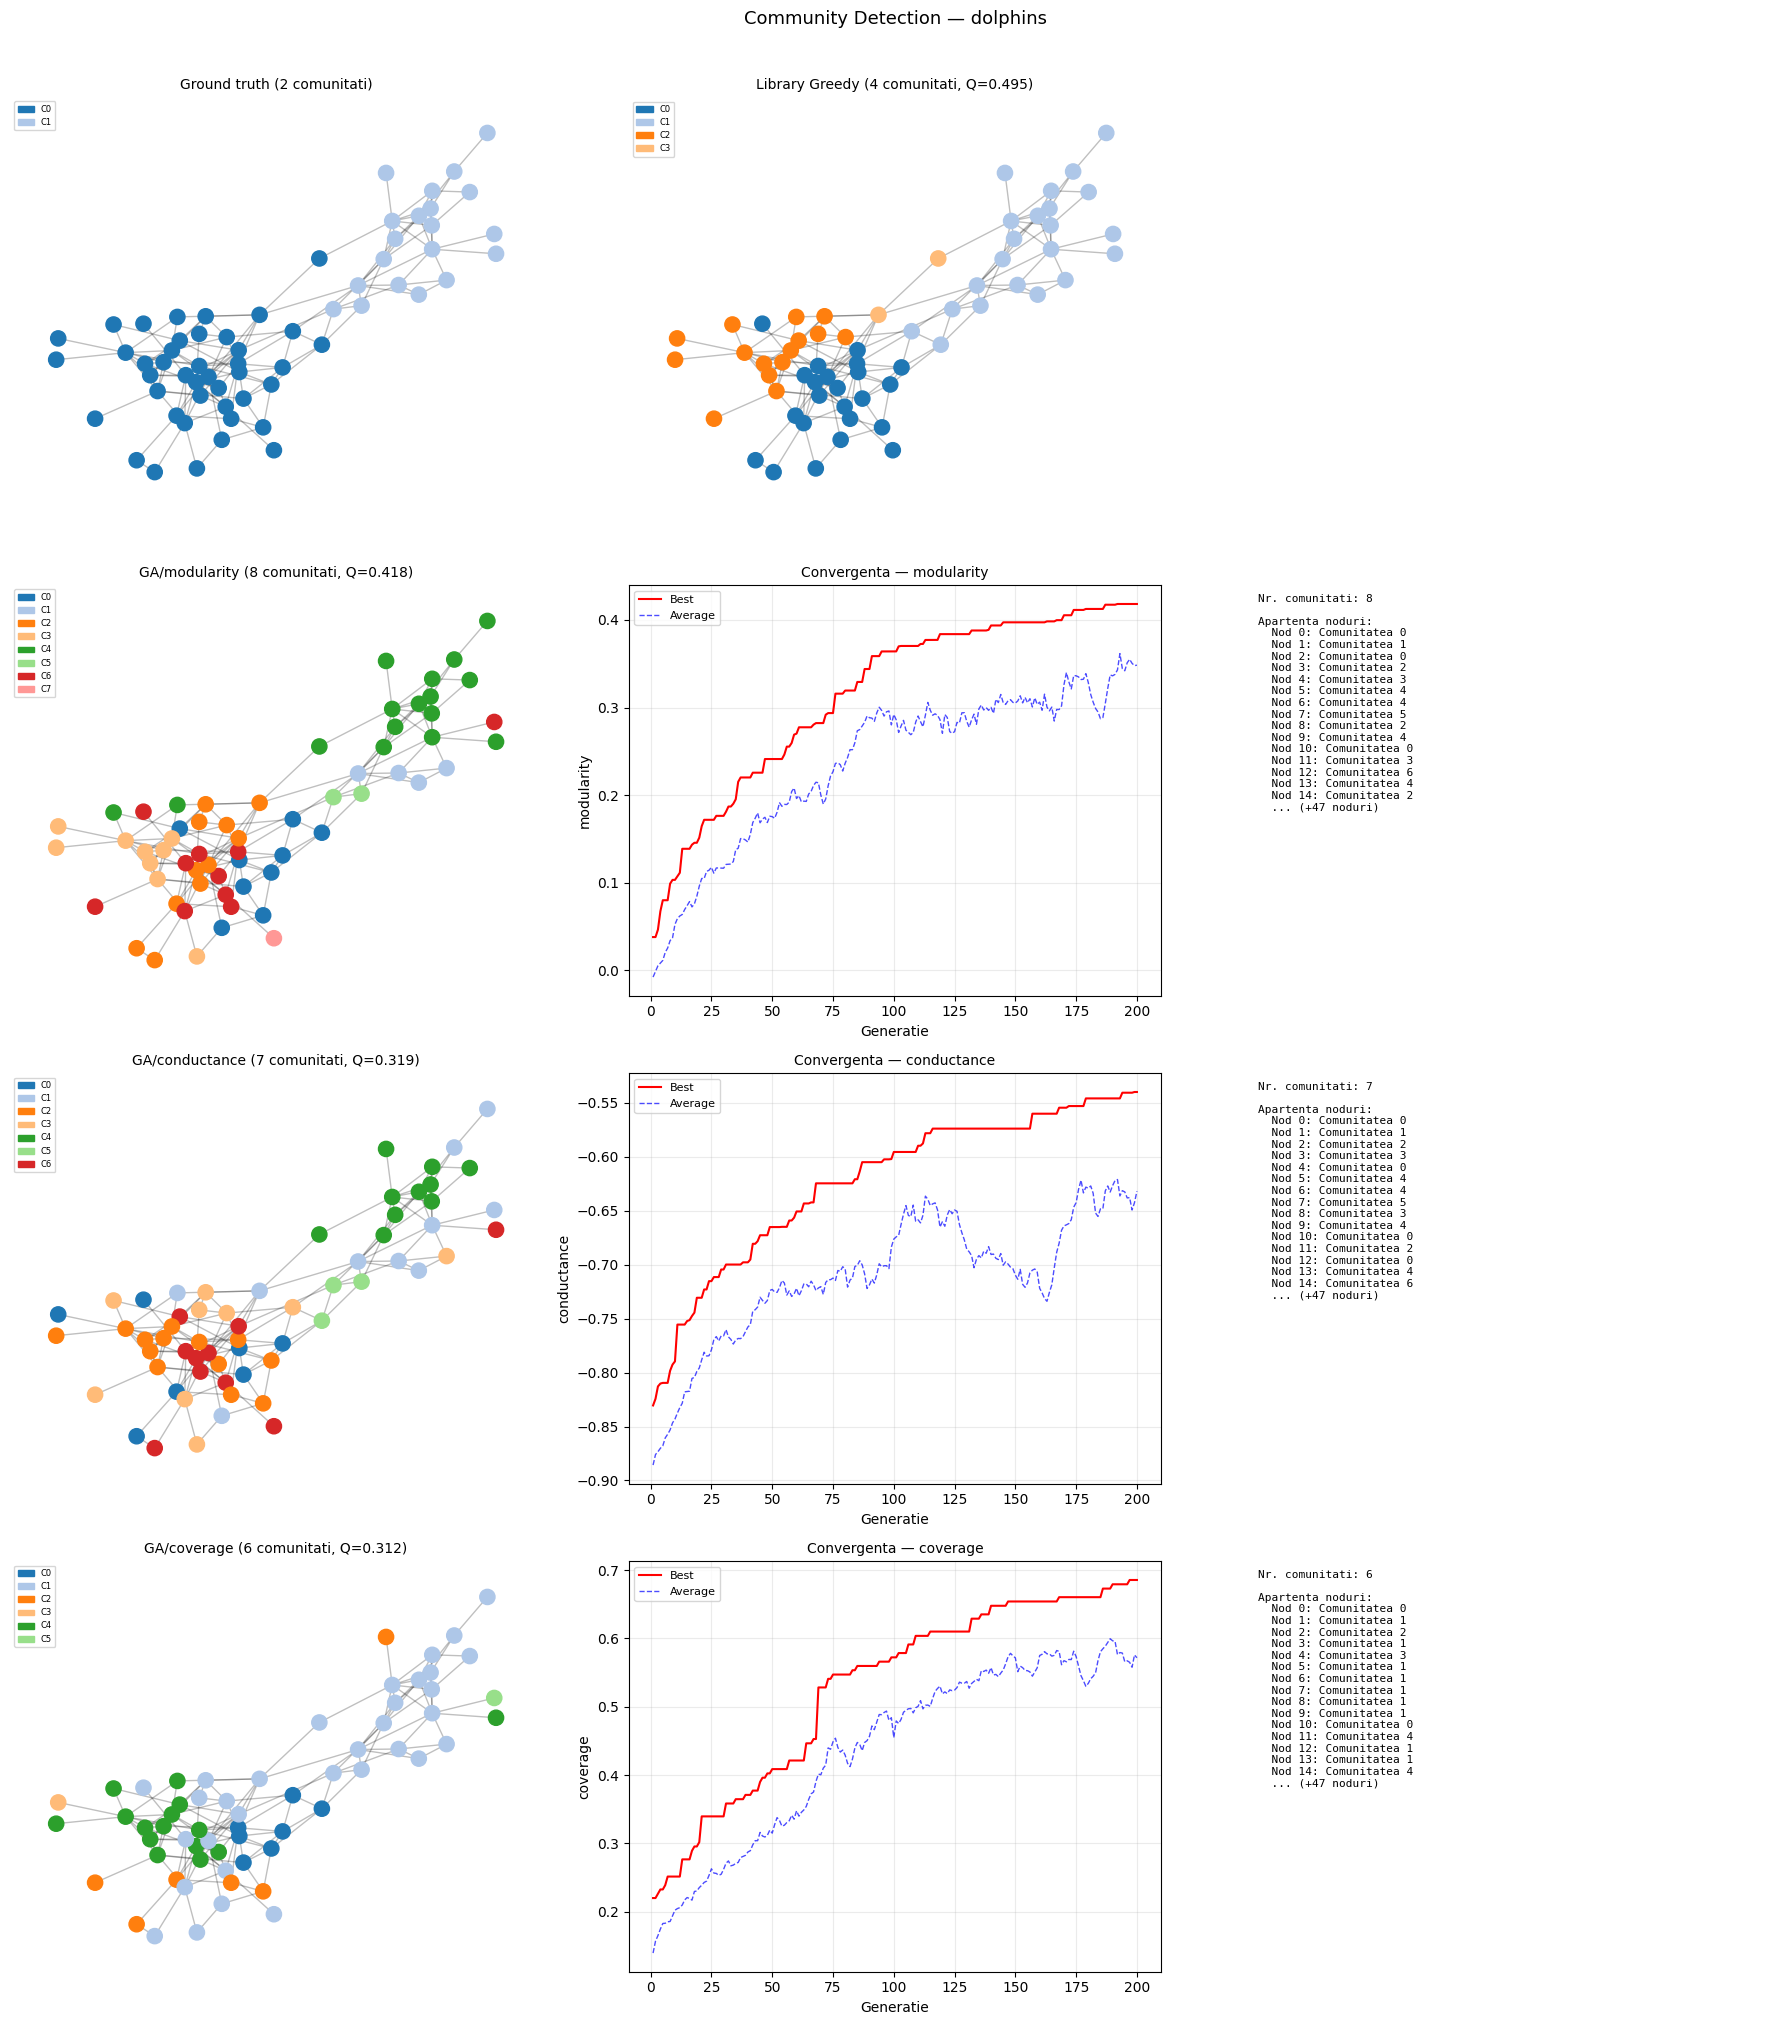

In [20]:
net_dolphins = load_gml_safe('real/dolphins/dolphins.gml')

gt_dolphins = load_ground_truth('real/dolphins/classLabeldolphins.txt', net_dolphins)

res_dolphins, fig_dolphins = run_experiment(
    net_dolphins,
    gt_labels   = gt_dolphins,
    ga_params   = GA_PARAMS['dolphins'],
    fitness_fns = FITNESS_TO_RUN,
    verbose     = True
)

# Retea 3 — Football (115 noduri, 613 muchii)


  Retea: FOOTBALL
  Noduri: 115 | Muchii: 613
  Comunitati reale: 12

[Library] Greedy Modularity...
Comunitati=6 | Q=0.5497 | Cond=-0.2779 | Cov=0.7308 | Timp=0.052s

[GA / modularity] pop=80 gen=300 pm=0.02
Gen   60/300 | Best modularity: 0.1090 | Avg: 0.0683 | Comunitati: 15 | Timp: 15.6s
Gen  120/300 | Best modularity: 0.1360 | Avg: 0.0790 | Comunitati: 15 | Timp: 34.2s
Gen  180/300 | Best modularity: 0.1532 | Avg: 0.0888 | Comunitati: 15 | Timp: 64.9s
Gen  240/300 | Best modularity: 0.1671 | Avg: 0.0999 | Comunitati: 15 | Timp: 85.2s
Gen  300/300 | Best modularity: 0.1864 | Avg: 0.1170 | Comunitati: 15 | Timp: 101.1s
  Comunitati=15 | Q=0.1864 | Cond=-0.7992 | Cov=0.2692 | Timp=101.4s

[GA / conductance] pop=80 gen=300 pm=0.02
Gen   60/300 | Best conductance: -0.8489 | Avg: -0.8837 | Comunitati: 15 | Timp: 1.6s
Gen  120/300 | Best conductance: -0.8223 | Avg: -0.8715 | Comunitati: 15 | Timp: 3.2s
Gen  180/300 | Best conductance: -0.8211 | Avg: -0.8739 | Comunitati: 15 | Timp: 4.8s

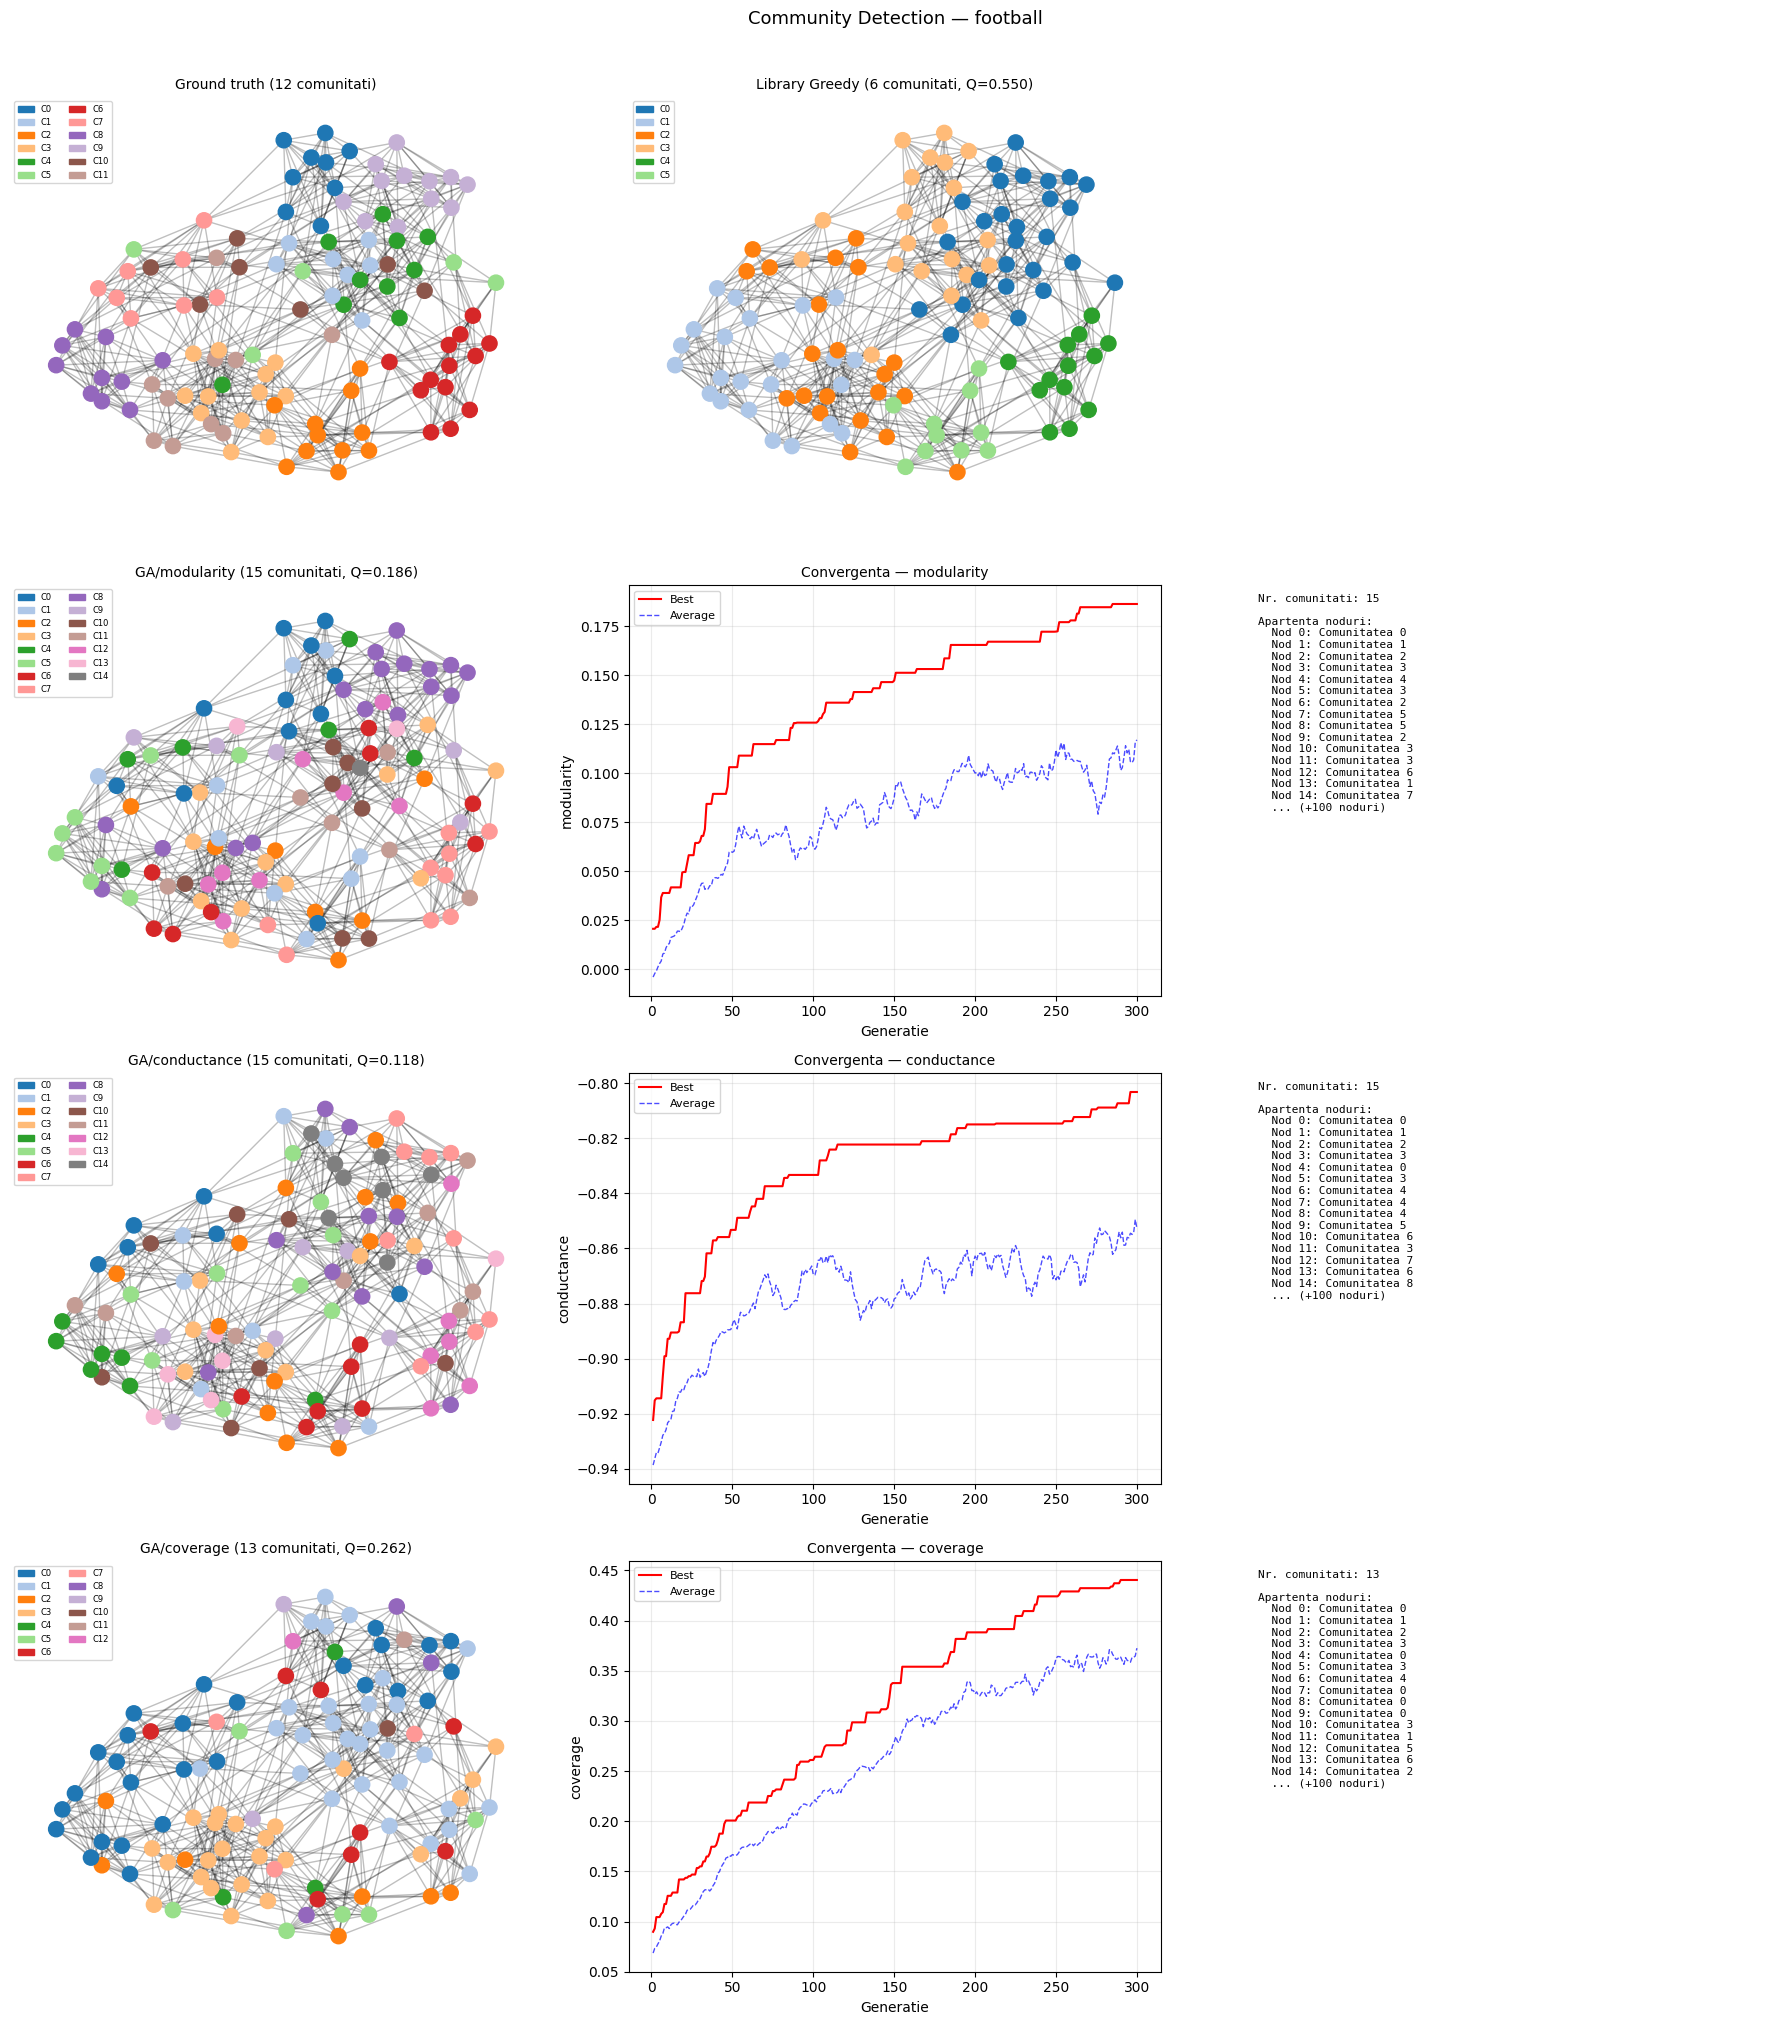

In [21]:
net_football = load_gml_safe('real/football/football.gml')

gt_football = load_ground_truth('real/football/classLabelfootball.txt', net_football)

res_football, fig_football = run_experiment(
    net_football,
    gt_labels   = gt_football,
    ga_params   = GA_PARAMS['football'],
    fitness_fns = FITNESS_TO_RUN,
    verbose     = True
)

# Retea 4 — Krebs (105 noduri, 441 muchii)


  Retea: KREBS
  Noduri: 105 | Muchii: 441
  Comunitati reale: 3

[Library] Greedy Modularity...
Comunitati=4 | Q=0.5020 | Cond=-0.2549 | Cov=0.9184 | Timp=0.029s

[GA / modularity] pop=70 gen=250 pm=0.02
Gen   50/250 | Best modularity: 0.1417 | Avg: 0.0877 | Comunitati: 10 | Timp: 14.1s
Gen  100/250 | Best modularity: 0.1611 | Avg: 0.1093 | Comunitati: 10 | Timp: 29.1s
Gen  150/250 | Best modularity: 0.1950 | Avg: 0.1415 | Comunitati: 10 | Timp: 43.1s
Gen  200/250 | Best modularity: 0.2250 | Avg: 0.1626 | Comunitati: 10 | Timp: 57.5s
Gen  250/250 | Best modularity: 0.2367 | Avg: 0.1738 | Comunitati: 10 | Timp: 72.0s
  Comunitati=10 | Q=0.2367 | Cond=-0.6920 | Cov=0.3741 | Timp=72.2s

[GA / conductance] pop=70 gen=250 pm=0.02
Gen   50/250 | Best conductance: -0.7654 | Avg: -0.8123 | Comunitati: 10 | Timp: 0.9s
Gen  100/250 | Best conductance: -0.7451 | Avg: -0.7936 | Comunitati: 10 | Timp: 1.7s
Gen  150/250 | Best conductance: -0.7190 | Avg: -0.7660 | Comunitati: 10 | Timp: 3.3s
Gen  

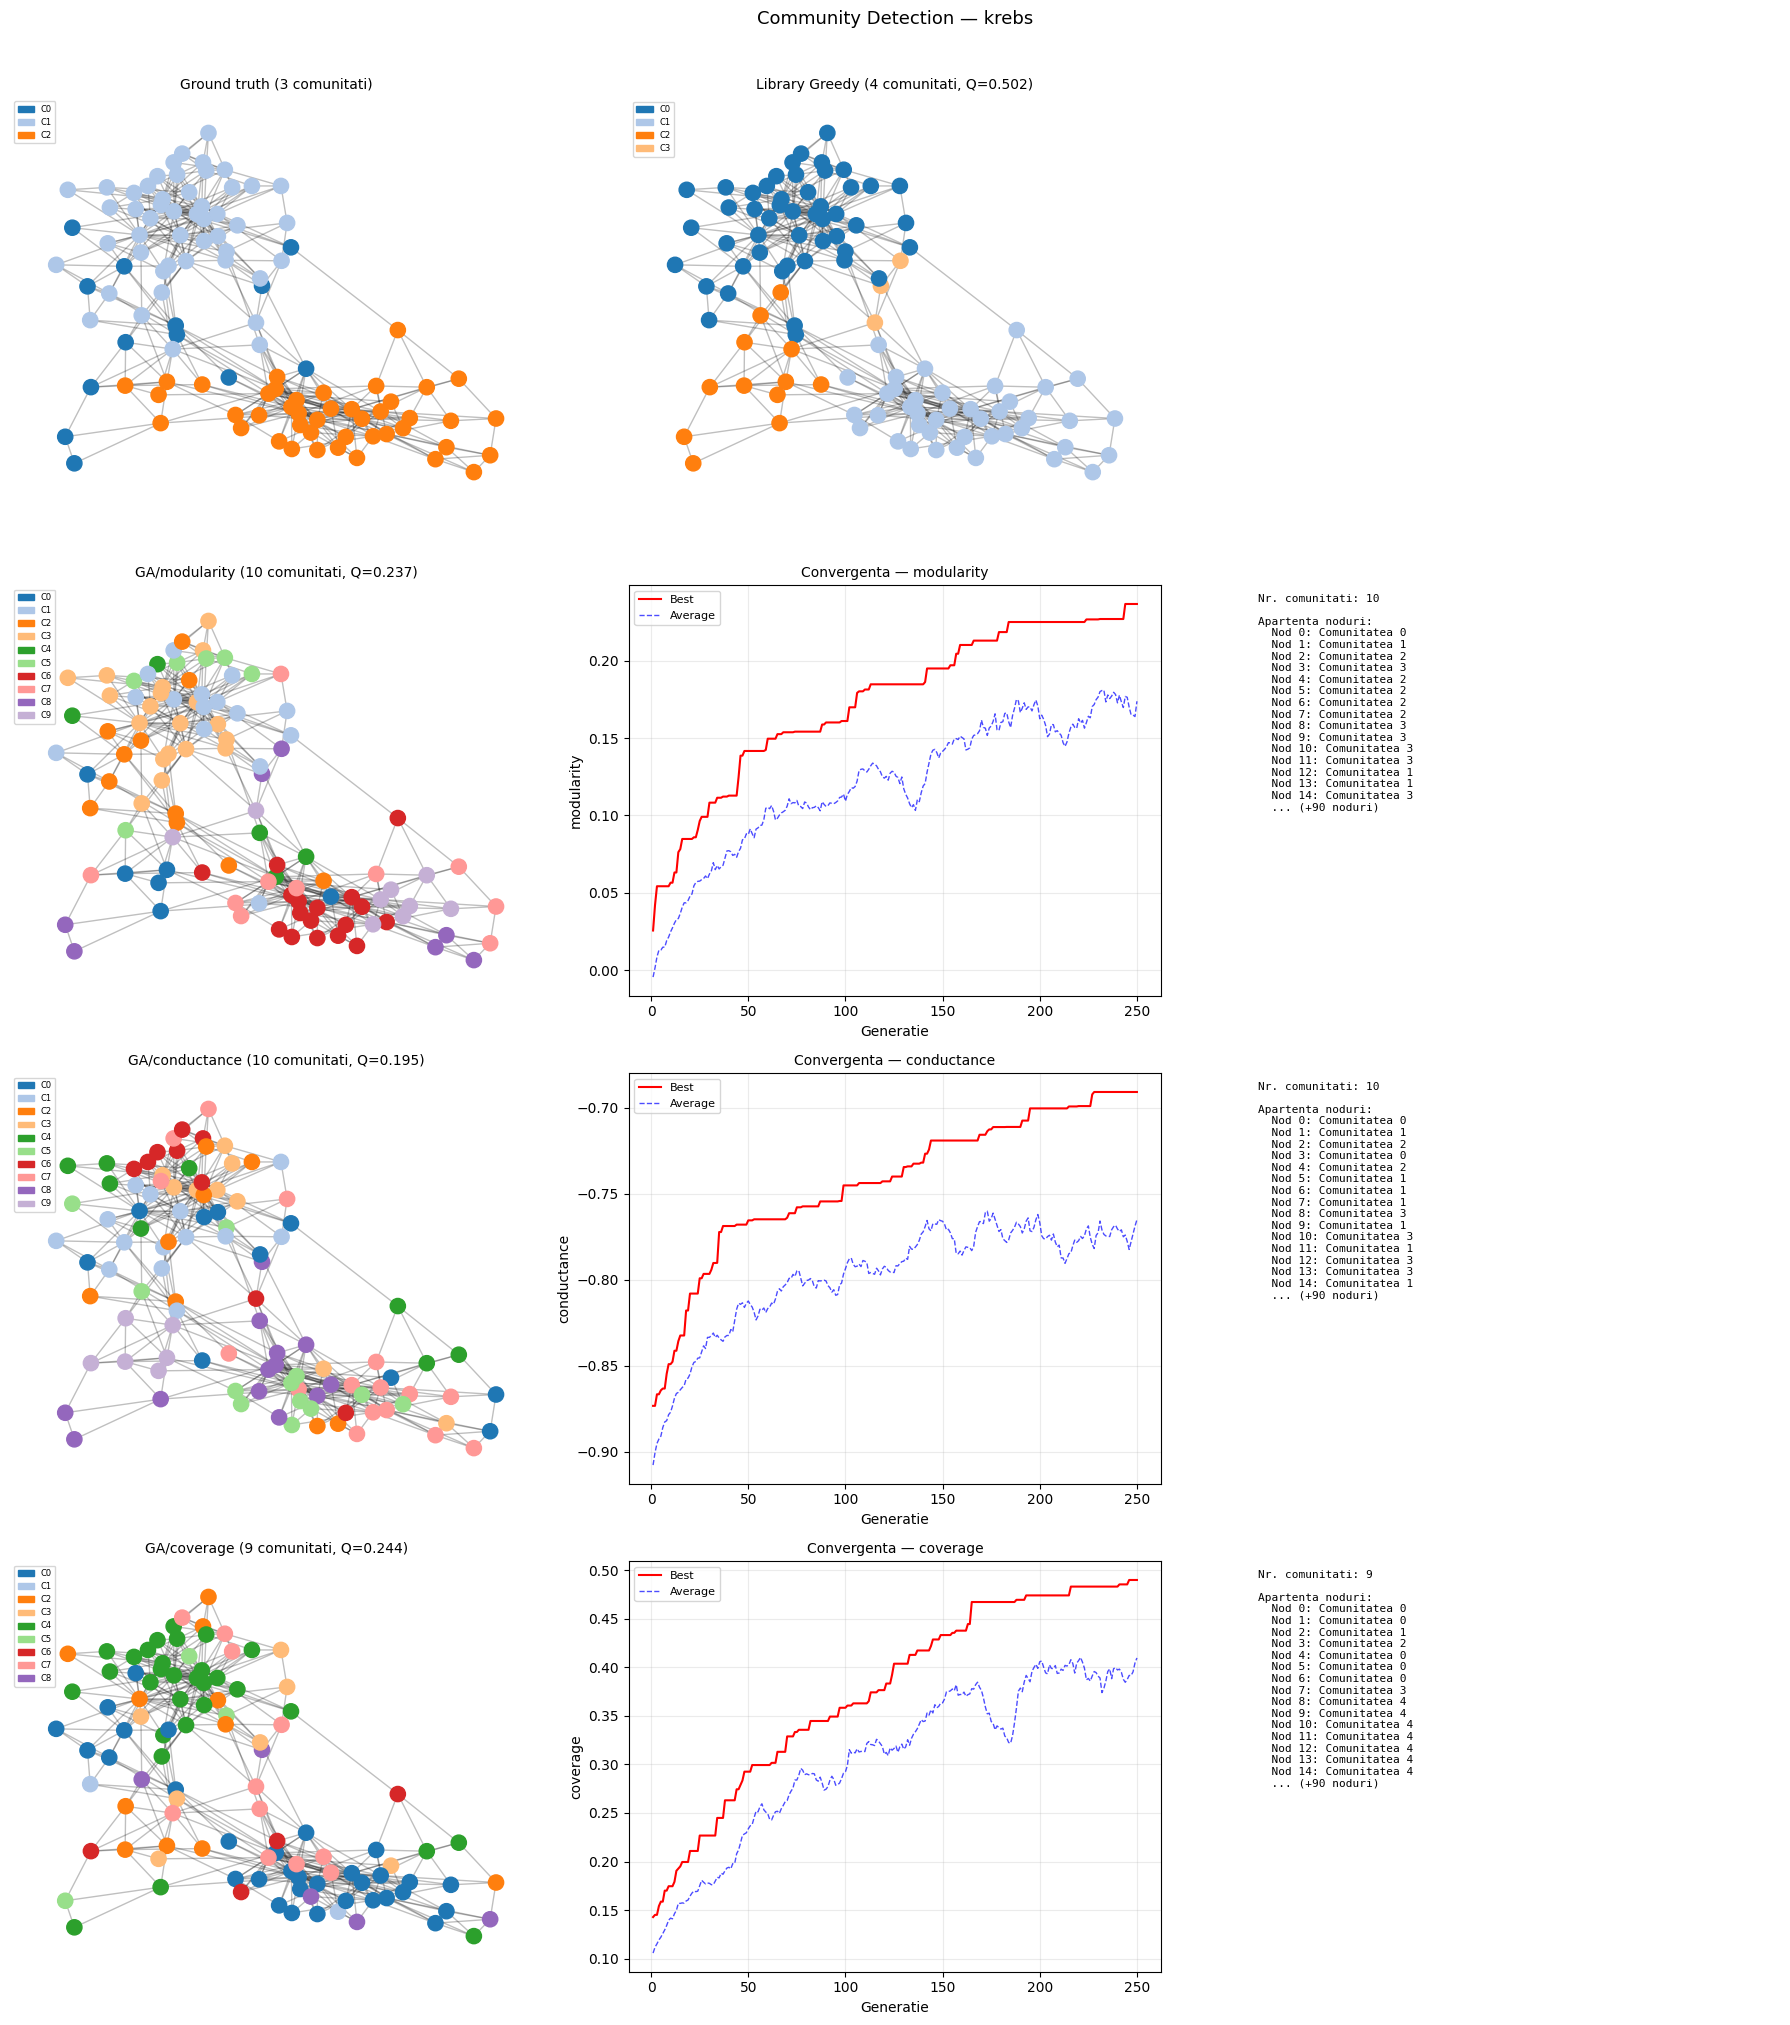

In [22]:
net_krebs = load_gml_safe('real/krebs/krebs.gml')

gt_krebs = load_ground_truth('real/krebs/classLabelkrebs.txt', net_krebs)

res_krebs, fig_krebs = run_experiment(
    net_krebs,
    gt_labels   = gt_krebs,
    ga_params   = GA_PARAMS['krebs'],
    fitness_fns = FITNESS_TO_RUN,
    verbose     = True
)

# RETELE PROPRII - PRELUATE DIN LIBRARIA NETWORKX

# Retea proprie 1 — Les Miserables (77 noduri, 254 muchii)

Les Miserables: 77 noduri, 254 muchii

  Retea: LES_MISERABLES
  Noduri: 77 | Muchii: 254

[Library] Greedy Modularity...
Comunitati=5 | Q=0.5360 | Cond=-0.2877 | Cov=0.0748 | Timp=0.023s

[GA / modularity] pop=60 gen=200 pm=0.02
Gen   40/200 | Best modularity: 1.3450 | Avg: 1.0050 | Comunitati: 10 | Timp: 5.2s
Gen   80/200 | Best modularity: 1.8798 | Avg: 1.5599 | Comunitati: 10 | Timp: 10.3s
Gen  120/200 | Best modularity: 2.1184 | Avg: 1.8757 | Comunitati: 10 | Timp: 17.7s
Gen  160/200 | Best modularity: 2.3277 | Avg: 1.8578 | Comunitati: 10 | Timp: 24.2s
Gen  200/200 | Best modularity: 2.4524 | Avg: 1.9623 | Comunitati: 10 | Timp: 32.2s
  Comunitati=10 | Q=2.4524 | Cond=-0.9158 | Cov=0.2047 | Timp=32.4s

[GA / conductance] pop=60 gen=200 pm=0.02
Gen   40/200 | Best conductance: -0.7309 | Avg: -0.8081 | Comunitati: 9 | Timp: 0.4s
Gen   80/200 | Best conductance: -0.6661 | Avg: -0.7488 | Comunitati: 9 | Timp: 0.9s
Gen  120/200 | Best conductance: -0.6440 | Avg: -0.7501 | Comunitati: 

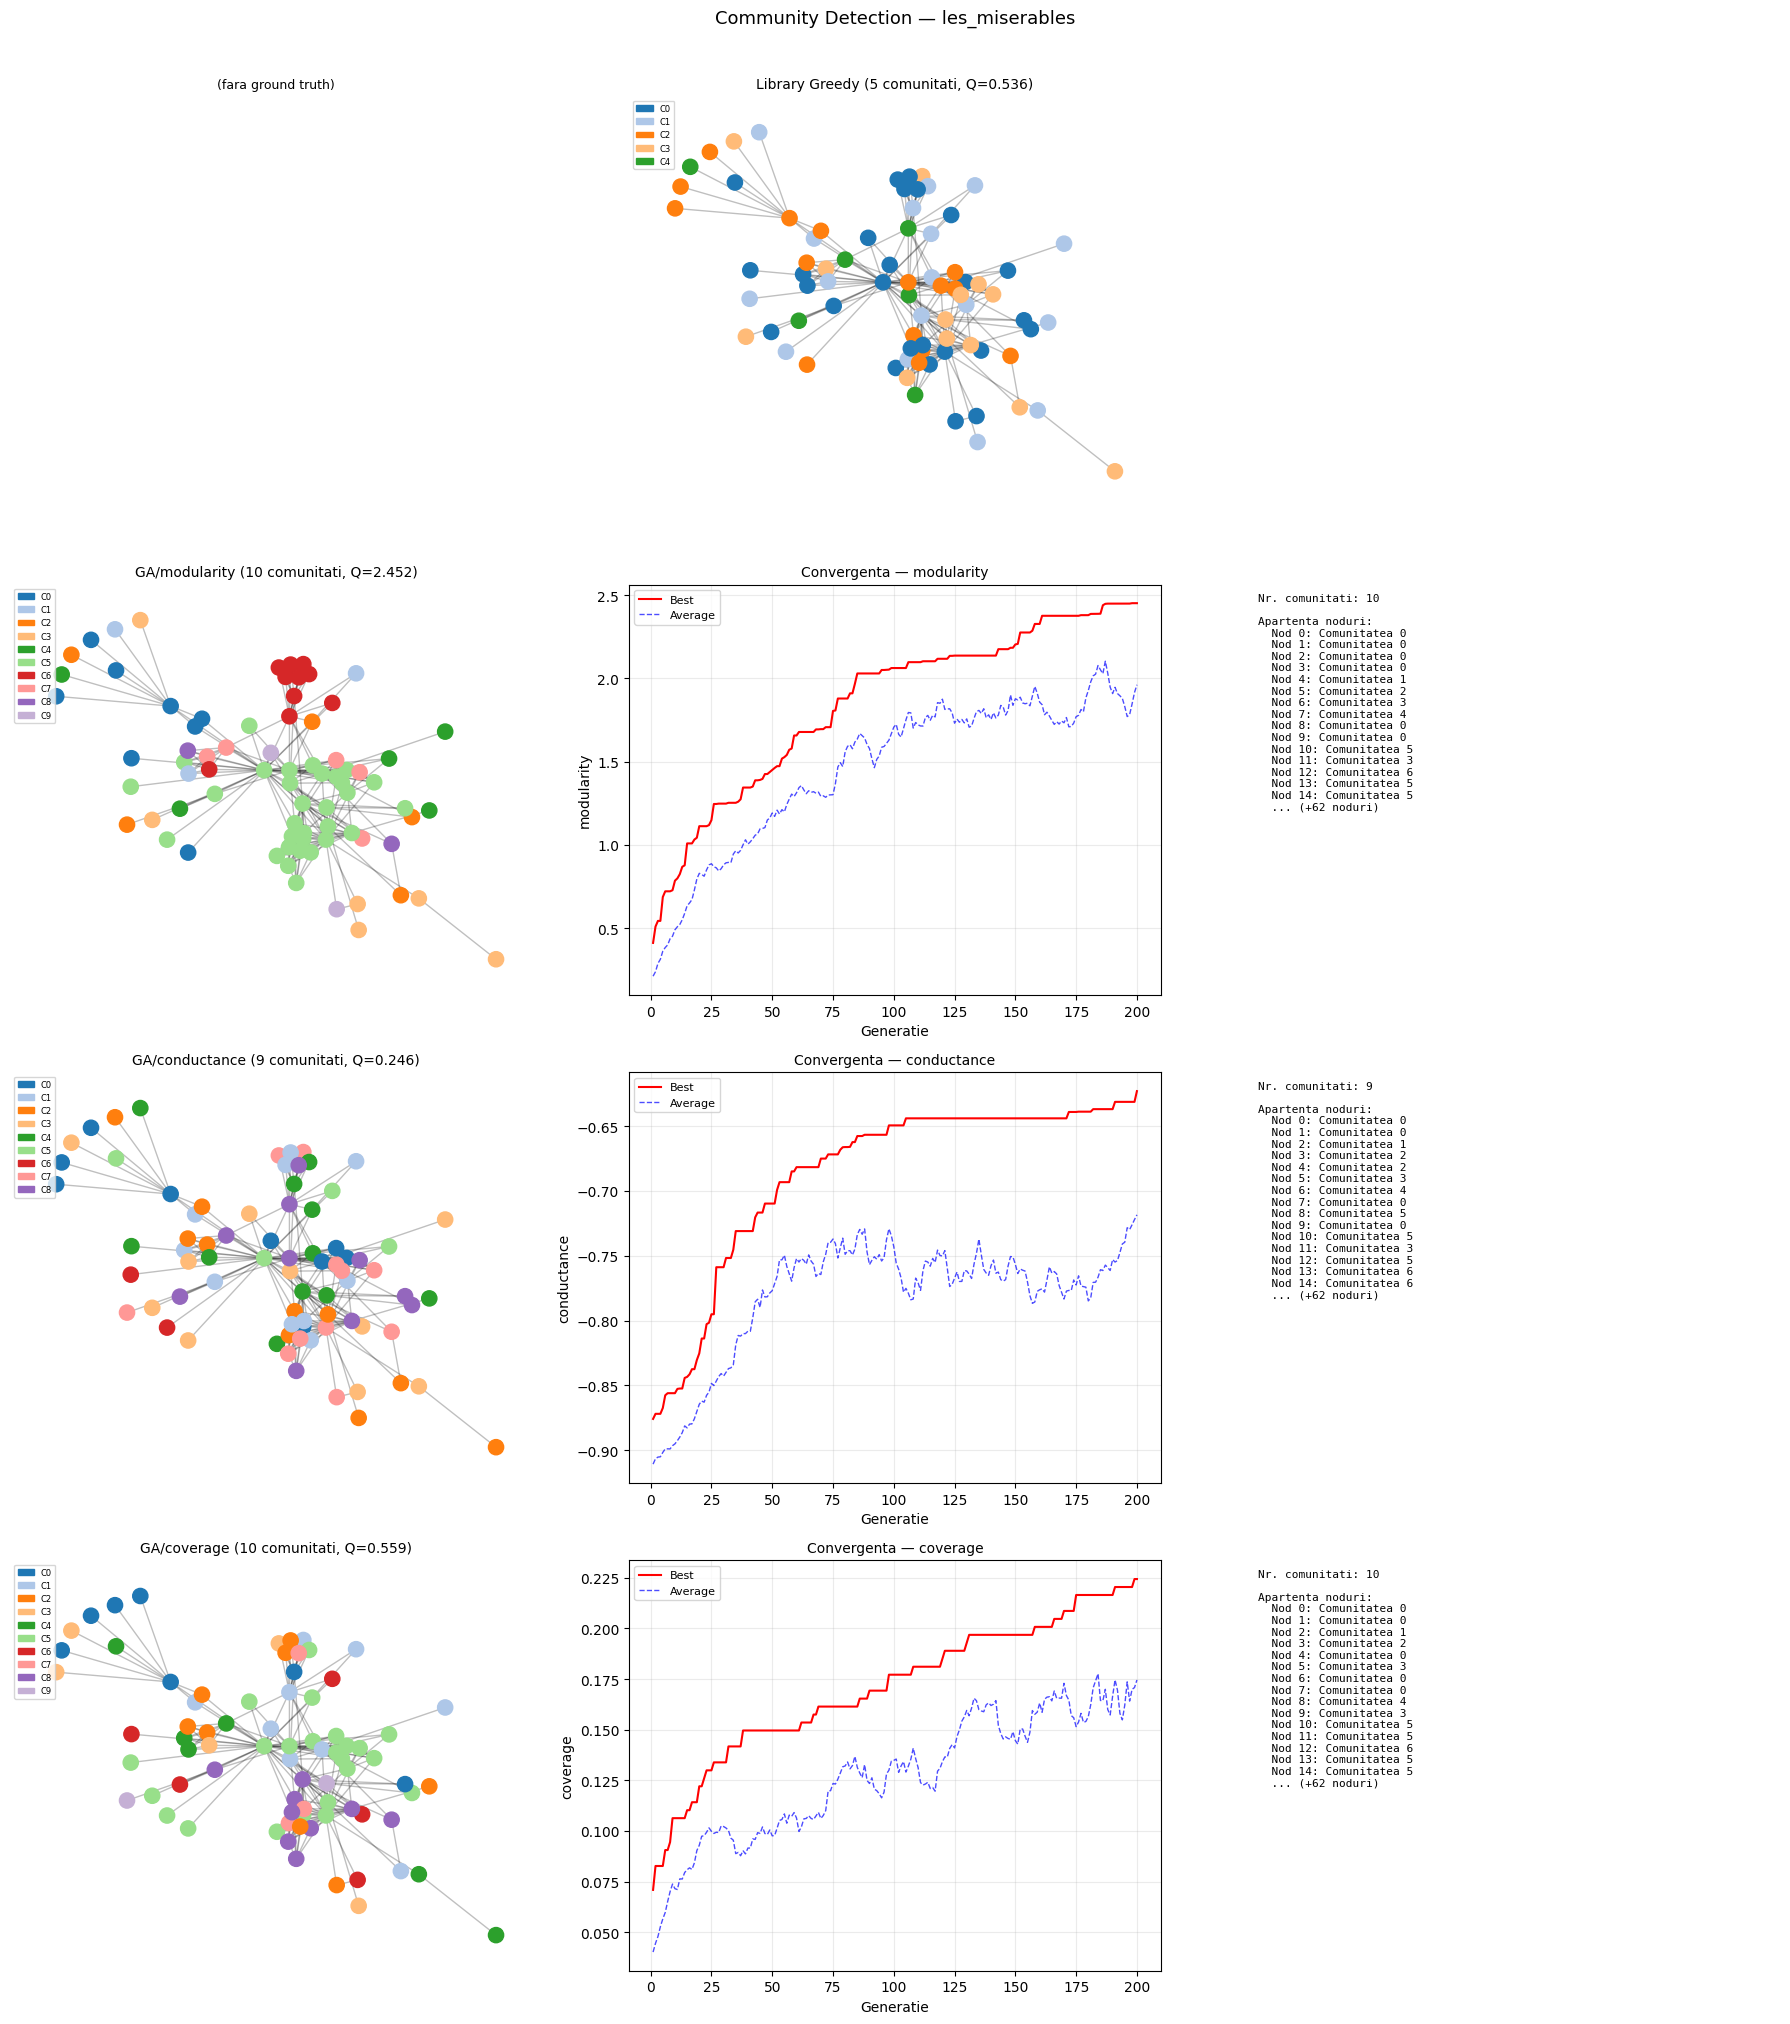

In [23]:
# Rețea de co-aparitii ale personajelor din romanul Les Miserables

net_les = load_networkx_builtin('les_miserables')
print(f"Les Miserables: {net_les['noNodes']} noduri, {net_les['noEdges']} muchii")

res_les, fig_les = run_experiment(
    net_les,
    gt_labels   = None,
    ga_params   = GA_PARAMS['les_miserables'],
    fitness_fns = FITNESS_TO_RUN,
    verbose     = True
)

# Retea proprie 2 — Davis Southern Women (32 noduri, 89 muchii)

Davis Women: 32 noduri, 89 muchii

  Retea: DAVIS_WOMEN
  Noduri: 32 | Muchii: 89

[Library] Greedy Modularity...
Comunitati=3 | Q=-0.0112 | Cond=-0.4064 | Cov=0.4045 | Timp=0.007s

[GA / modularity] pop=50 gen=150 pm=0.03
Gen   30/150 | Best modularity: 0.2543 | Avg: 0.1742 | Comunitati: 6 | Timp: 1.3s
Gen   60/150 | Best modularity: 0.3009 | Avg: 0.2454 | Comunitati: 6 | Timp: 2.2s
Gen   90/150 | Best modularity: 0.3244 | Avg: 0.2518 | Comunitati: 6 | Timp: 3.2s
Gen  120/150 | Best modularity: 0.3335 | Avg: 0.1873 | Comunitati: 6 | Timp: 4.1s
Gen  150/150 | Best modularity: 0.3421 | Avg: 0.2284 | Comunitati: 6 | Timp: 5.1s
  Comunitati=6 | Q=0.3421 | Cond=-0.8656 | Cov=0.5506 | Timp=5.1s

[GA / conductance] pop=50 gen=150 pm=0.03
Gen   30/150 | Best conductance: -0.6347 | Avg: -0.7524 | Comunitati: 5 | Timp: 0.1s
Gen   60/150 | Best conductance: -0.5760 | Avg: -0.6758 | Comunitati: 5 | Timp: 0.2s
Gen   90/150 | Best conductance: -0.5746 | Avg: -0.7248 | Comunitati: 5 | Timp: 0.3s
Gen

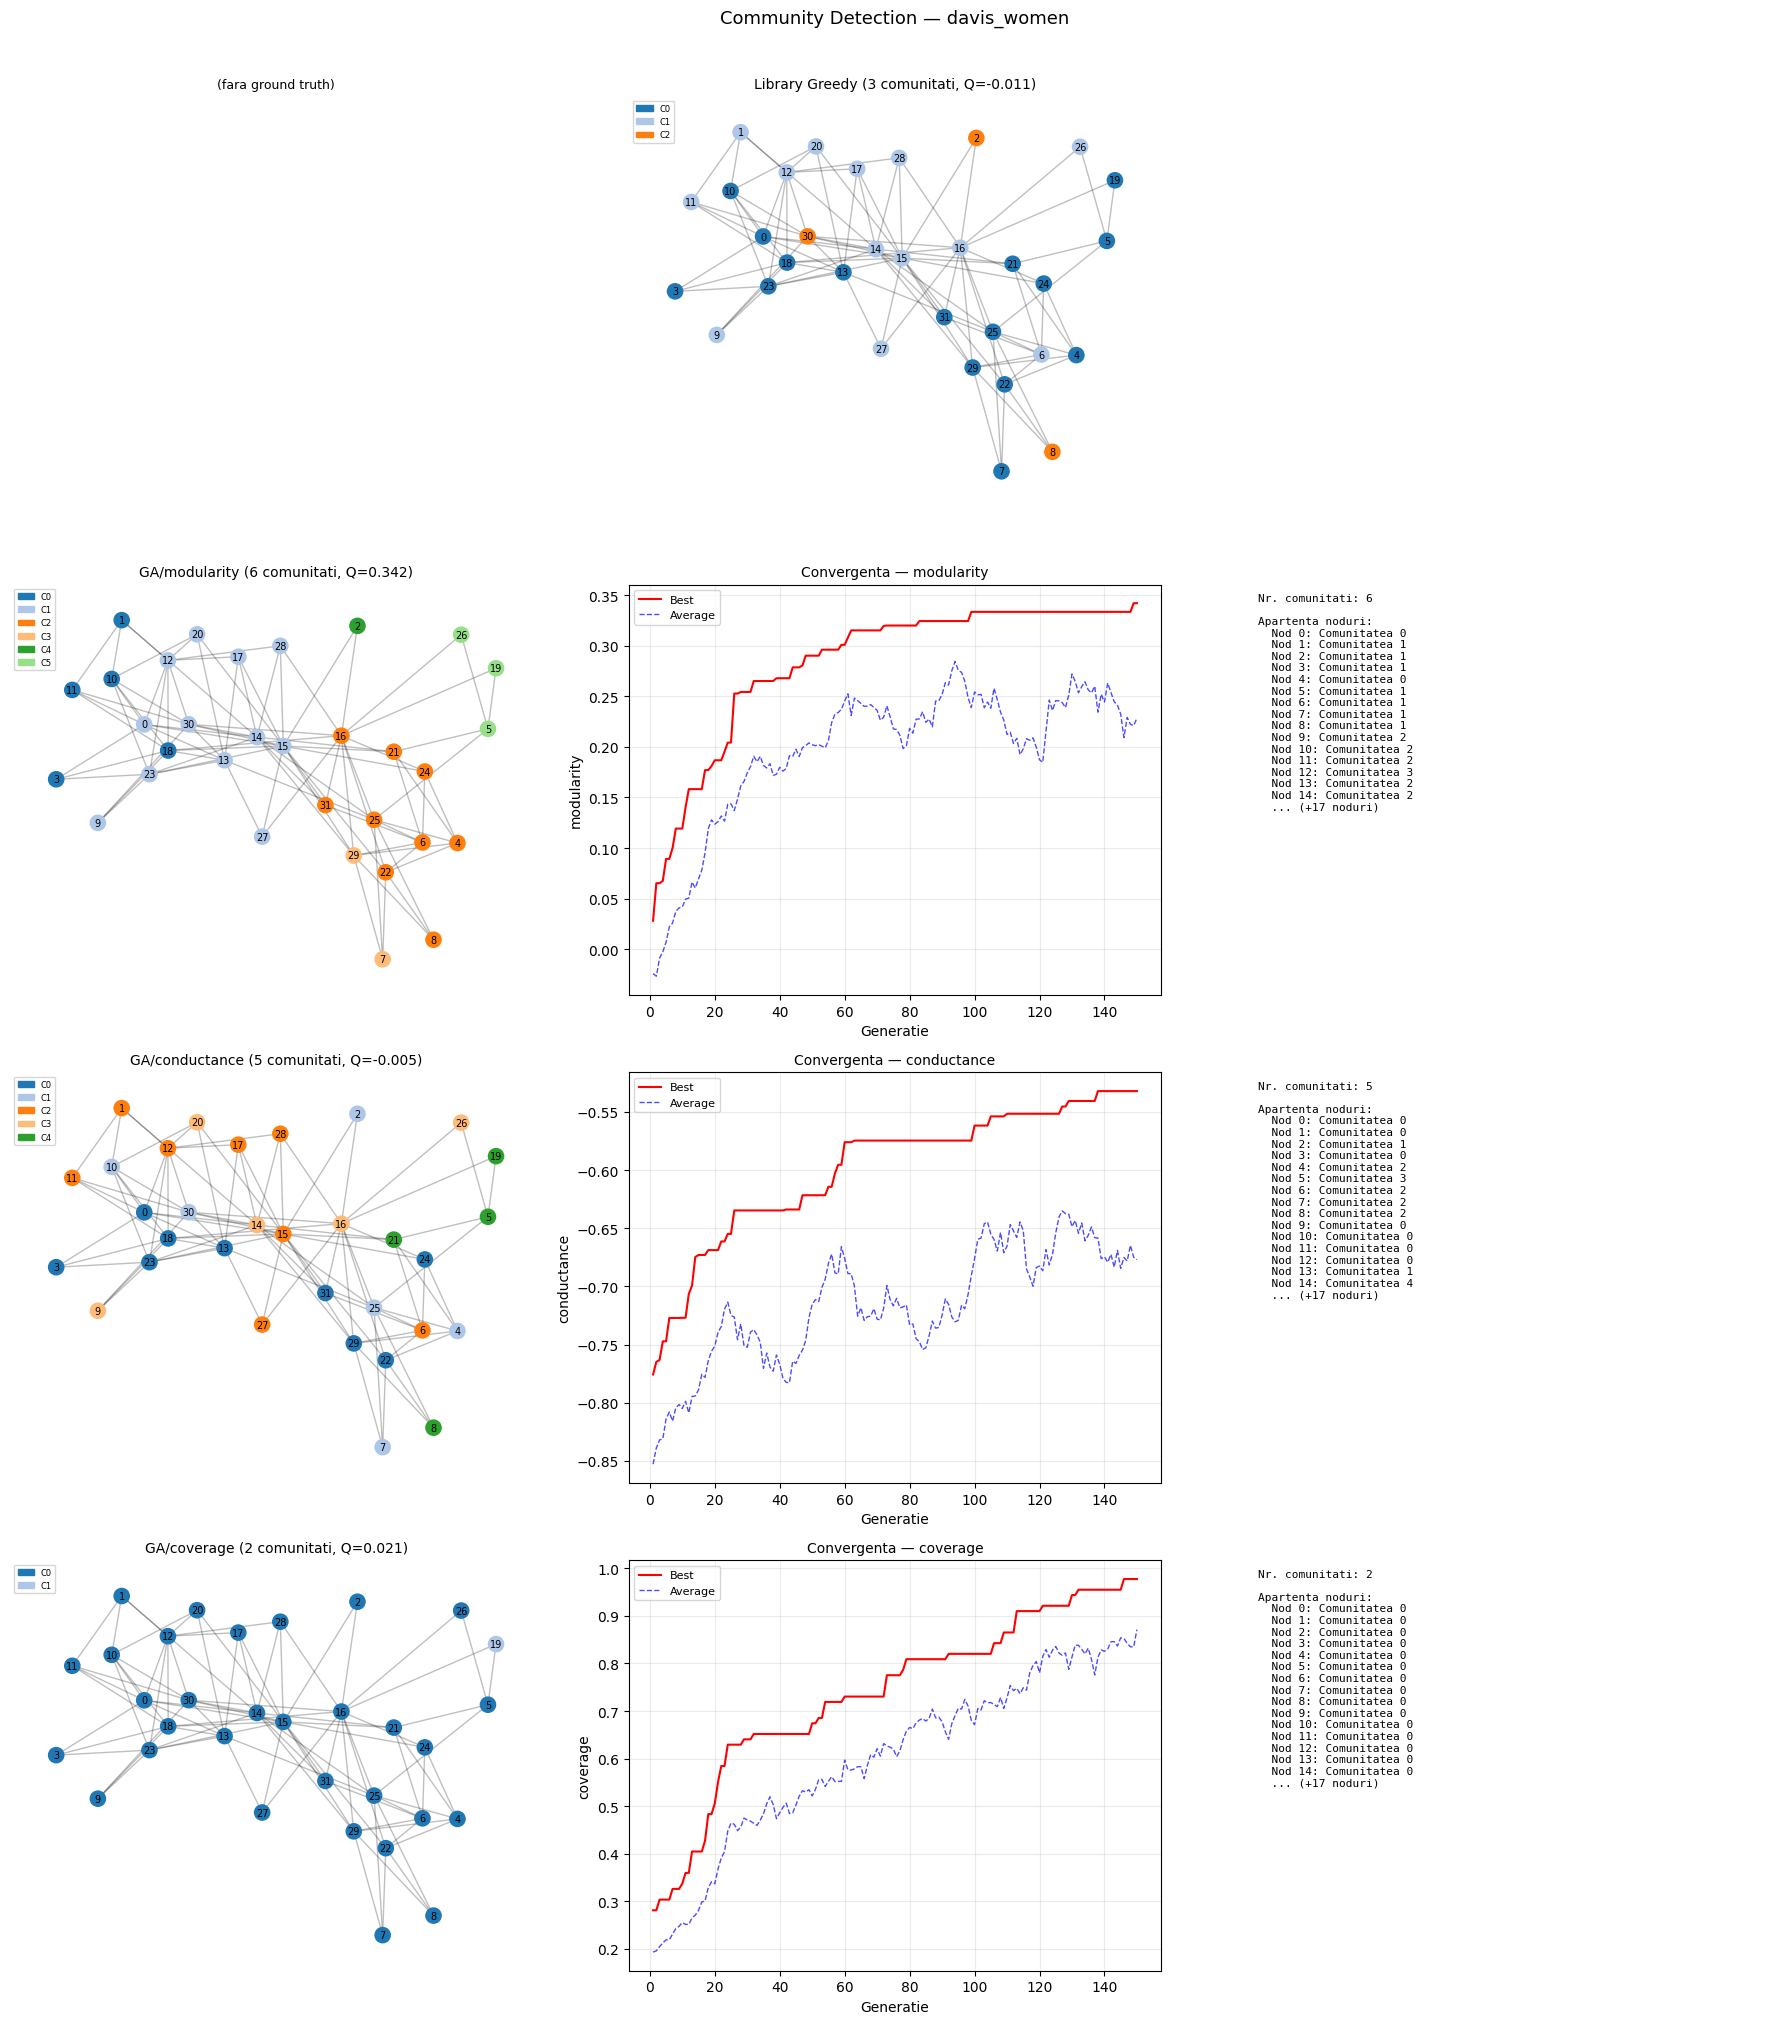

In [24]:
# Retea bipartita: femei din sudul SUA si evenimentele sociale la care au participat

net_davis = load_networkx_builtin('davis_women')
print(f"Davis Women: {net_davis['noNodes']} noduri, {net_davis['noEdges']} muchii")

res_davis, fig_davis = run_experiment(
    net_davis,
    gt_labels   = None,
    ga_params   = GA_PARAMS['davis_women'],
    fitness_fns = FITNESS_TO_RUN,
    verbose     = True
)

# Retea proprie 3 — Florentine Families (15 noduri, 20 muchii)

Florentine: 15 noduri, 20 muchii

  Retea: FLORENTINE
  Noduri: 15 | Muchii: 20

[Library] Greedy Modularity...
Comunitati=3 | Q=0.1487 | Cond=-0.2611 | Cov=0.5000 | Timp=0.003s

[GA / modularity] pop=50 gen=150 pm=0.03
Gen   30/150 | Best modularity: 0.3950 | Avg: 0.3449 | Comunitati: 4 | Timp: 0.2s
Gen   60/150 | Best modularity: 0.4263 | Avg: 0.3631 | Comunitati: 4 | Timp: 0.5s
Gen   90/150 | Best modularity: 0.4263 | Avg: 0.3735 | Comunitati: 4 | Timp: 0.8s
Gen  120/150 | Best modularity: 0.4263 | Avg: 0.3662 | Comunitati: 4 | Timp: 1.1s
Gen  150/150 | Best modularity: 0.4263 | Avg: 0.3816 | Comunitati: 4 | Timp: 1.4s
  Comunitati=4 | Q=0.4263 | Cond=-0.8814 | Cov=0.7000 | Timp=1.4s

[GA / conductance] pop=50 gen=150 pm=0.03
Gen   30/150 | Best conductance: -0.4017 | Avg: -0.5652 | Comunitati: 3 | Timp: 0.1s
Gen   60/150 | Best conductance: -0.3056 | Avg: -0.4335 | Comunitati: 3 | Timp: 0.1s
Gen   90/150 | Best conductance: -0.2611 | Avg: -0.3611 | Comunitati: 3 | Timp: 0.2s
Gen  1

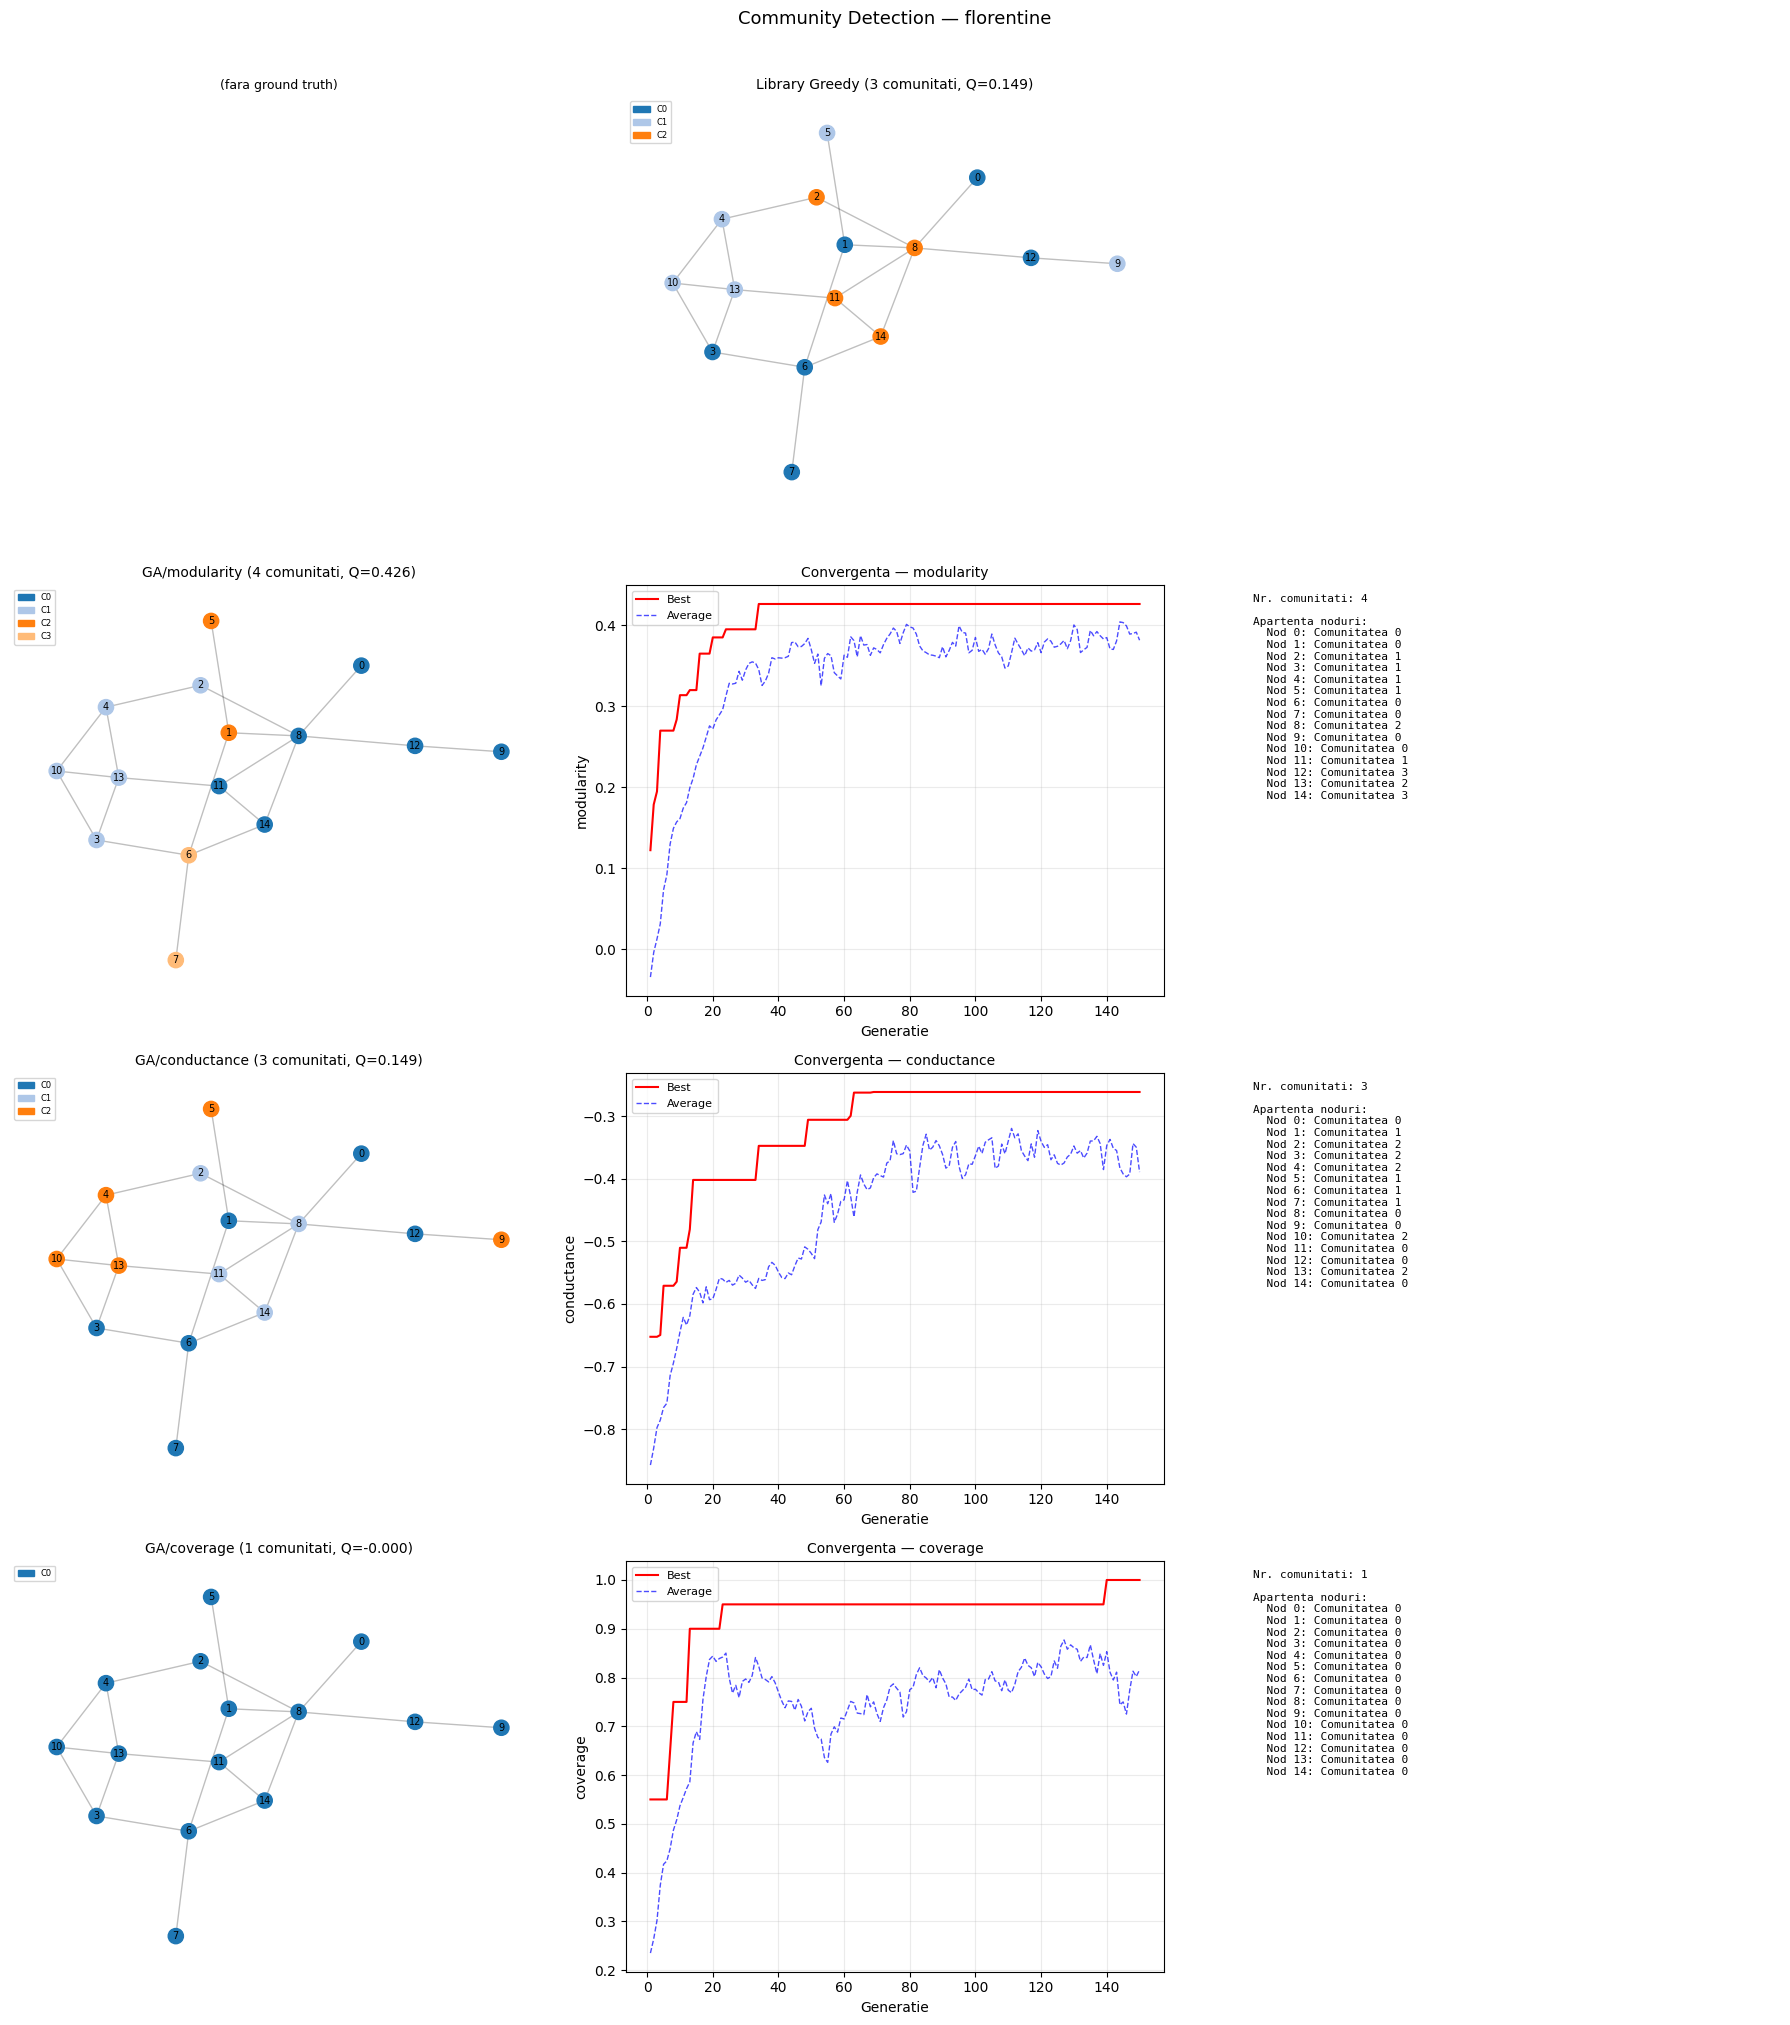

In [25]:
# Relatii de casatorie intre familiile florentine din Renastere (inclusiv Medici)

net_flor = load_networkx_builtin('florentine')
print(f"Florentine: {net_flor['noNodes']} noduri, {net_flor['noEdges']} muchii")

res_flor, fig_flor = run_experiment(
    net_flor,
    gt_labels   = None,
    ga_params   = GA_PARAMS['florentine'],
    fitness_fns = FITNESS_TO_RUN,
    verbose     = True
)

# Retea proprie 4 — Petersen Graph (10 noduri, 15 muchii)

Petersen: 10 noduri, 15 muchii

  Retea: PETERSEN
  Noduri: 10 | Muchii: 15

[Library] Greedy Modularity...
Comunitati=5 | Q=0.1333 | Cond=-0.6667 | Cov=0.3333 | Timp=0.001s

[GA / modularity] pop=50 gen=100 pm=0.05
Gen   20/100 | Best modularity: 0.1667 | Avg: 0.0879 | Comunitati: 2 | Timp: 0.2s
Gen   40/100 | Best modularity: 0.1667 | Avg: 0.1235 | Comunitati: 2 | Timp: 0.4s
Gen   60/100 | Best modularity: 0.1667 | Avg: 0.1312 | Comunitati: 2 | Timp: 0.7s
Gen   80/100 | Best modularity: 0.1667 | Avg: 0.1223 | Comunitati: 2 | Timp: 0.9s
Gen  100/100 | Best modularity: 0.1667 | Avg: 0.1157 | Comunitati: 2 | Timp: 1.2s
  Comunitati=2 | Q=0.1667 | Cond=-0.3333 | Cov=0.6667 | Timp=1.2s

[GA / conductance] pop=50 gen=100 pm=0.05
Gen   20/100 | Best conductance: -0.4667 | Avg: -0.6078 | Comunitati: 2 | Timp: 0.1s
Gen   40/100 | Best conductance: -0.3333 | Avg: -0.4551 | Comunitati: 2 | Timp: 0.1s
Gen   60/100 | Best conductance: -0.3333 | Avg: -0.4647 | Comunitati: 2 | Timp: 0.2s
Gen   80/1

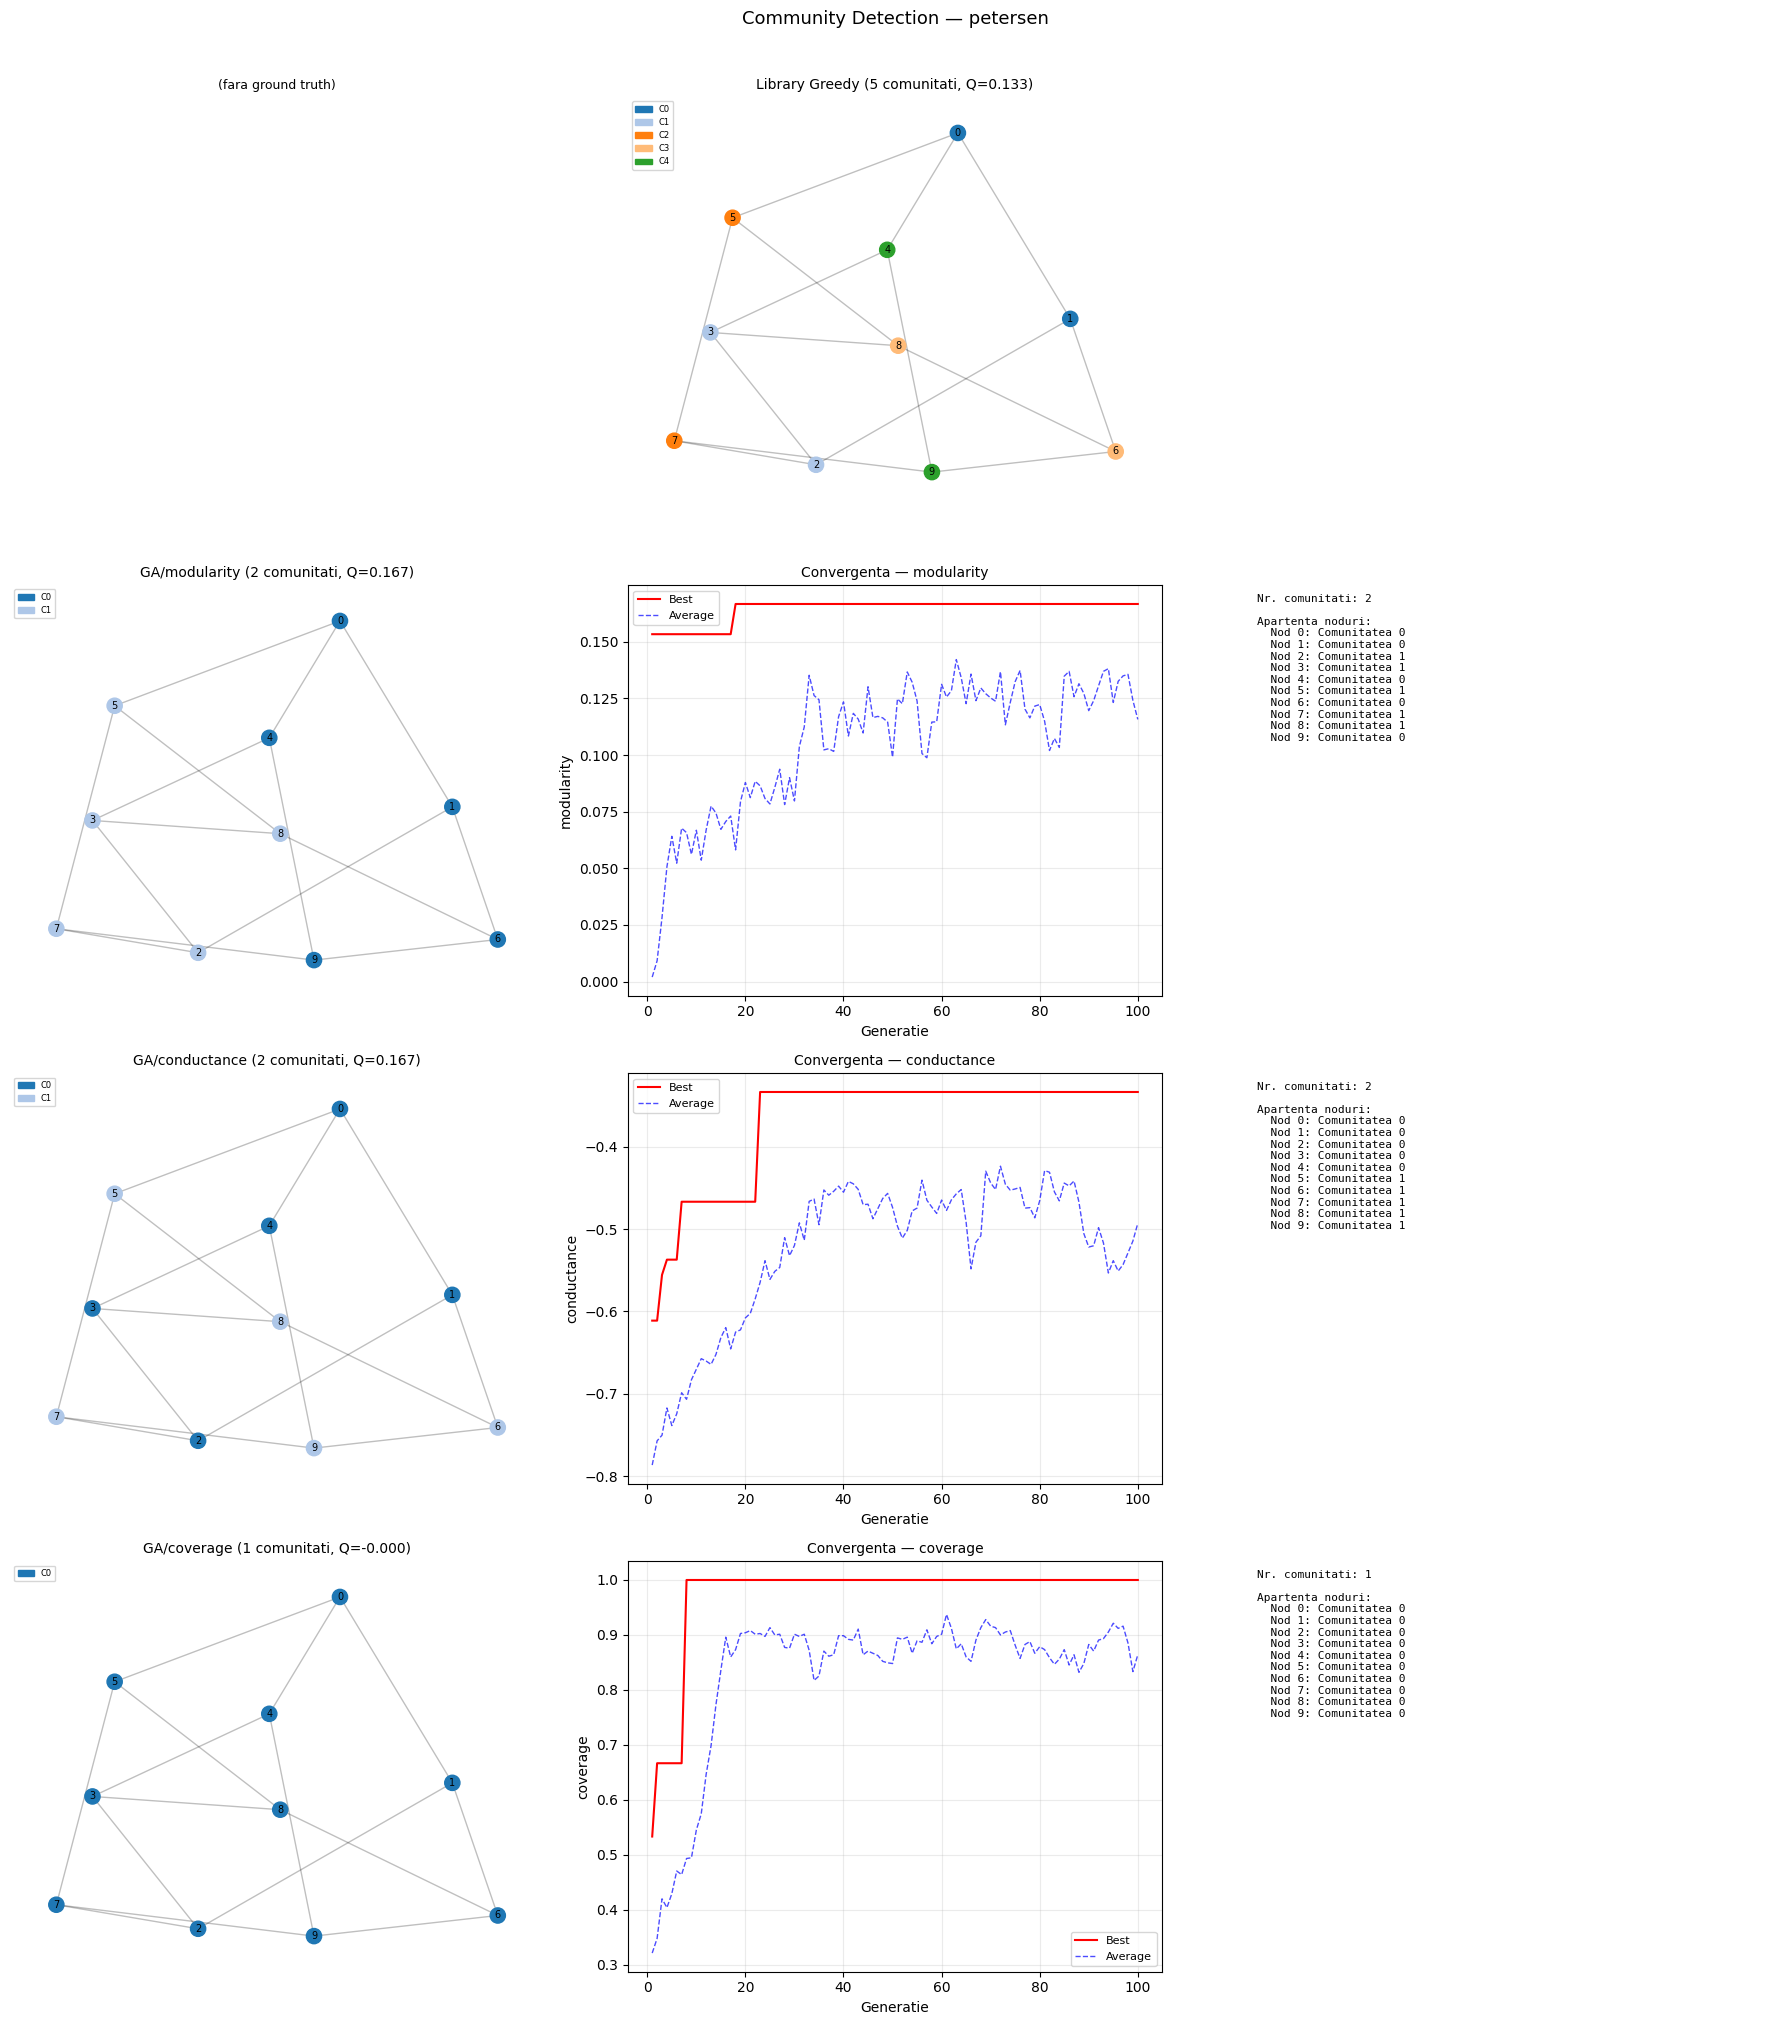

In [26]:
# Graf clasic din teoria grafurilor: simetric, 3-regulat

net_pet = load_networkx_builtin('petersen')
print(f"Petersen: {net_pet['noNodes']} noduri, {net_pet['noEdges']} muchii")

res_pet, fig_pet = run_experiment(
    net_pet,
    gt_labels   = None,
    ga_params   = GA_PARAMS['petersen'],
    fitness_fns = FITNESS_TO_RUN,
    verbose     = True
)

# Retea proprie 5: Florentine Dense (Căsătorii + Aliante Economice)

Florentine Dense: 15 noduri, 21 muchii

  Retea: FLORENTINE_DENSE
  Noduri: 15 | Muchii: 21

[Library] Greedy Modularity...
Comunitati=3 | Q=0.1293 | Cond=-0.3000 | Cov=0.4762 | Timp=0.001s

[GA / modularity] pop=60 gen=150 pm=0.03
Gen   30/150 | Best modularity: 0.3866 | Avg: 0.3356 | Comunitati: 5 | Timp: 0.4s
Gen   60/150 | Best modularity: 0.4002 | Avg: 0.3744 | Comunitati: 4 | Timp: 0.9s
Gen   90/150 | Best modularity: 0.4002 | Avg: 0.3554 | Comunitati: 4 | Timp: 1.4s
Gen  120/150 | Best modularity: 0.4002 | Avg: 0.3472 | Comunitati: 4 | Timp: 1.9s
Gen  150/150 | Best modularity: 0.4002 | Avg: 0.3449 | Comunitati: 4 | Timp: 2.4s
  Comunitati=4 | Q=0.4002 | Cond=-0.9444 | Cov=0.8095 | Timp=2.4s

[GA / conductance] pop=60 gen=150 pm=0.03
Gen   30/150 | Best conductance: -0.4214 | Avg: -0.4894 | Comunitati: 4 | Timp: 0.1s
Gen   60/150 | Best conductance: -0.3000 | Avg: -0.4467 | Comunitati: 3 | Timp: 0.2s
Gen   90/150 | Best conductance: -0.3000 | Avg: -0.3872 | Comunitati: 3 | Timp:

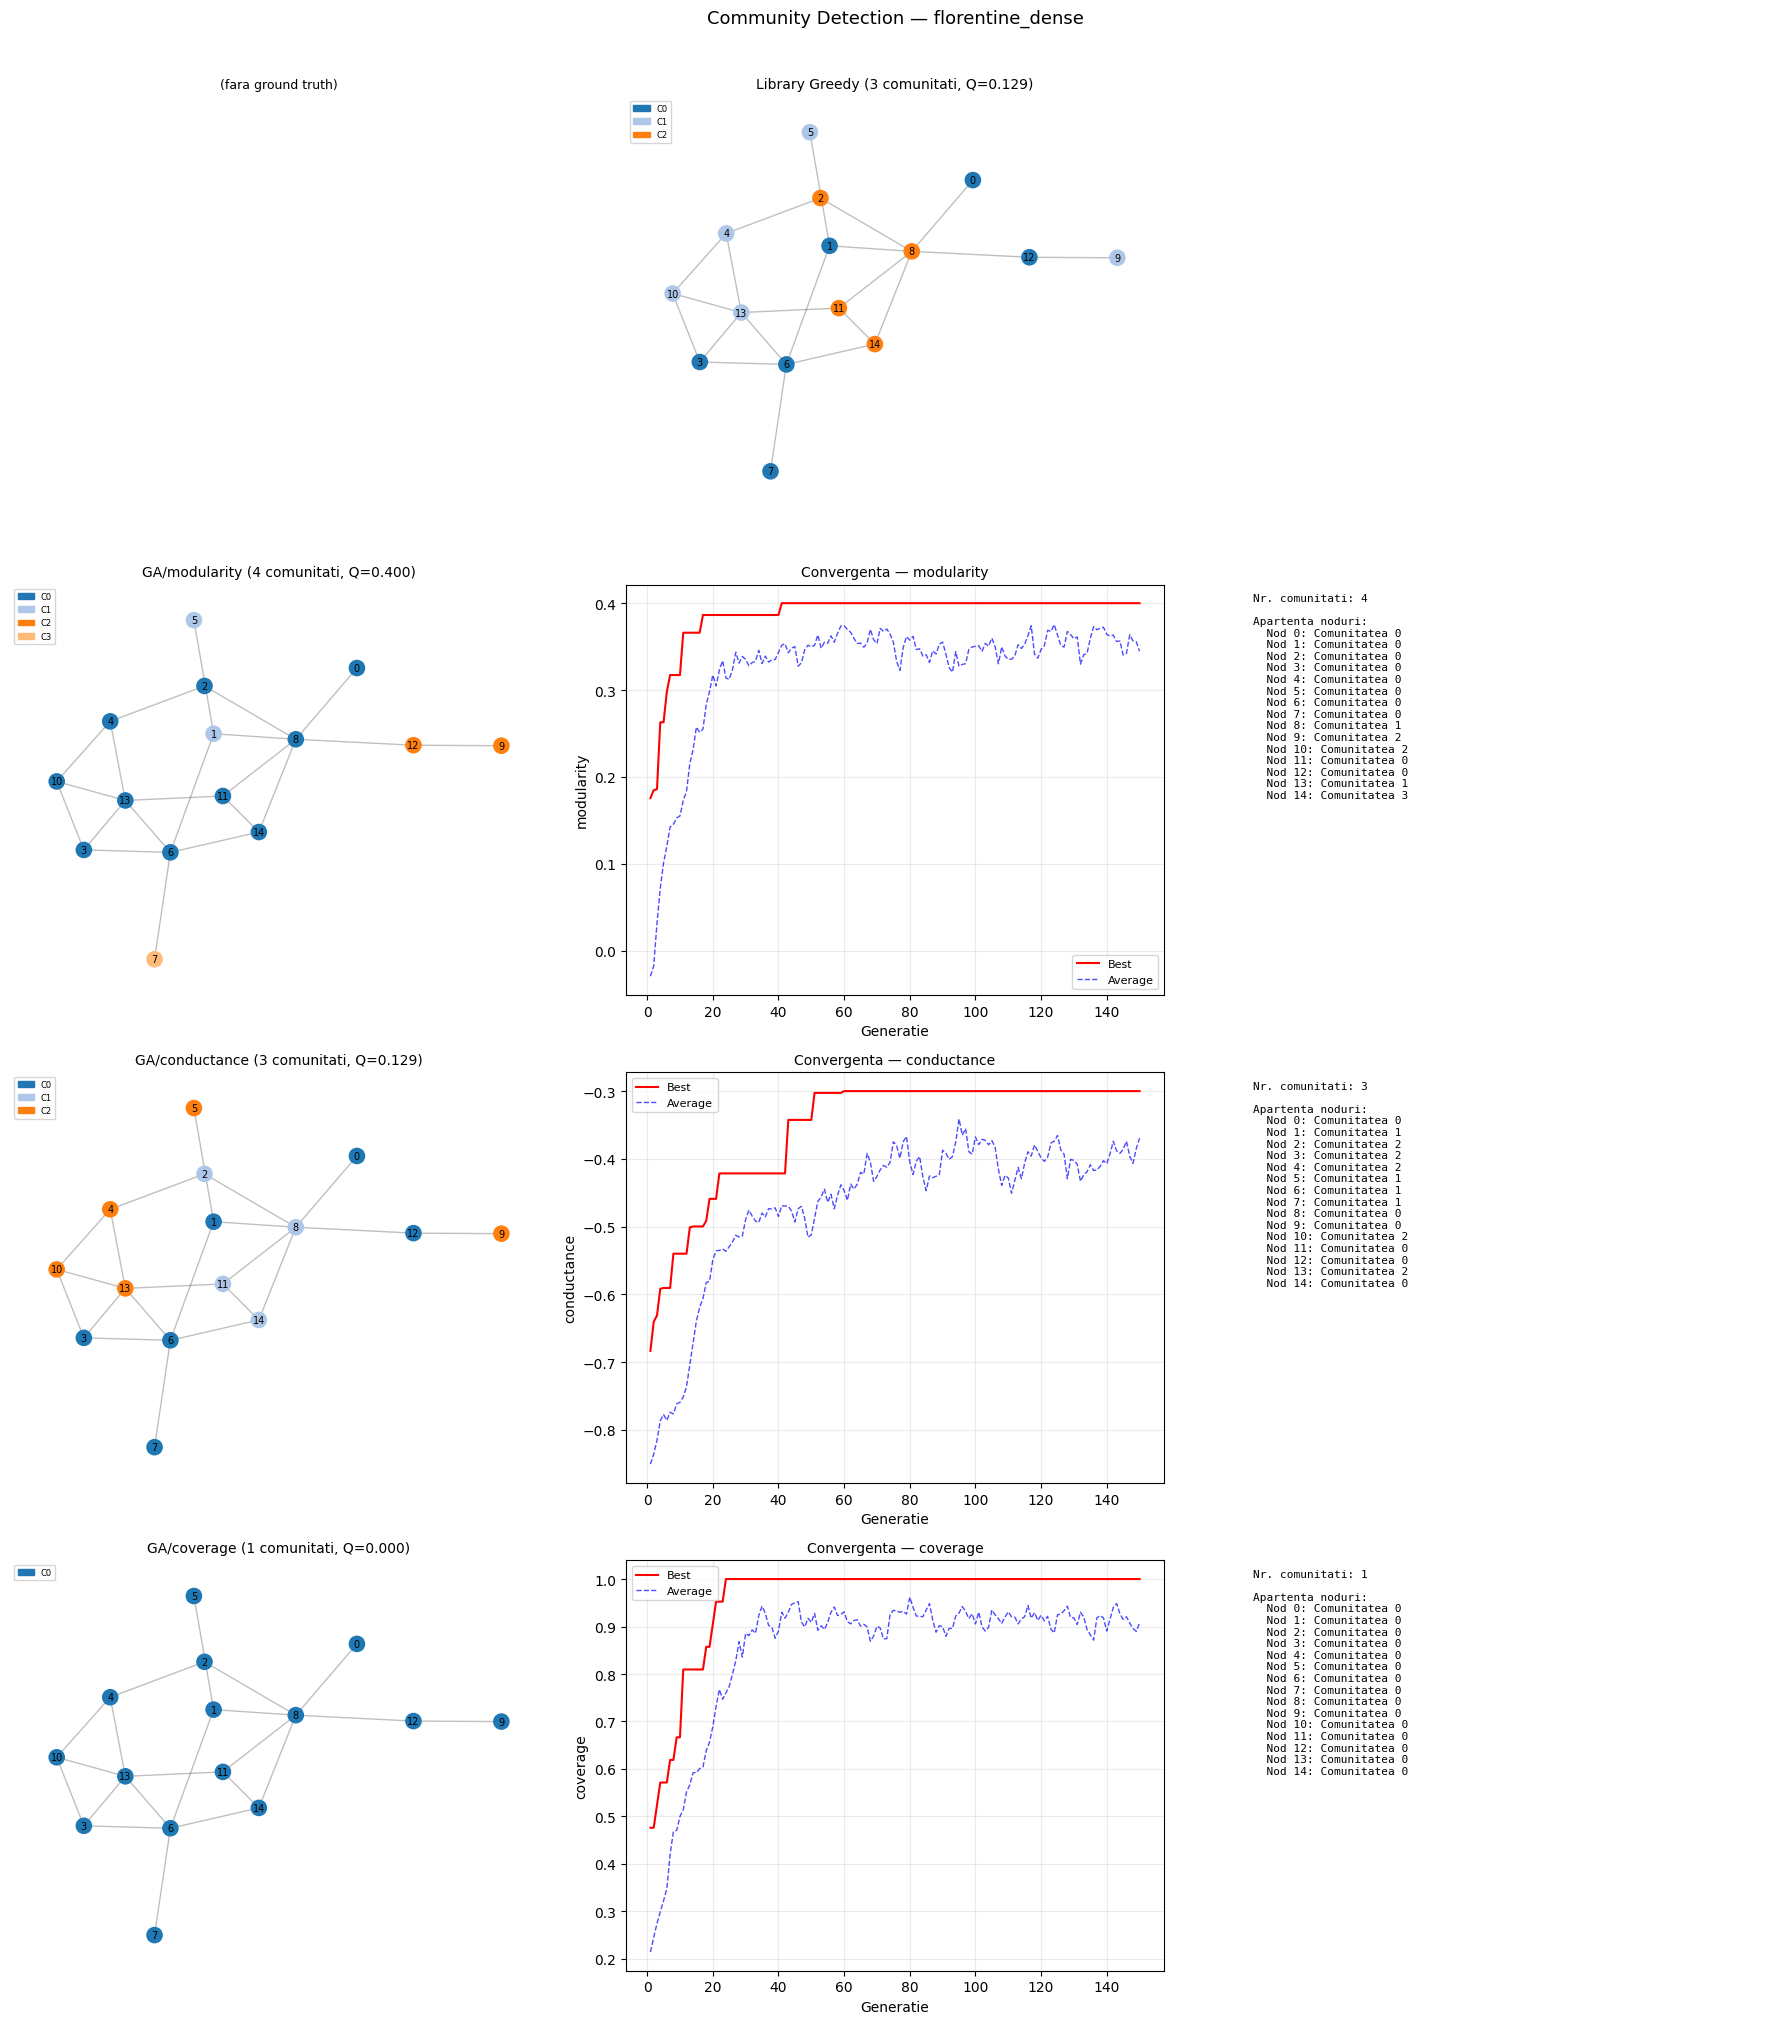

In [27]:
net_flo_d = load_networkx_builtin('florentine_dense')
print(f"Florentine Dense: {net_flo_d['noNodes']} noduri, {net_flo_d['noEdges']} muchii")

res_sbm1, _ = run_experiment(
    net_flo_d,
    gt_labels   = None,
    ga_params   = GA_PARAMS['florentine_dense'],
    fitness_fns = FITNESS_TO_RUN,
    verbose     = True
)

# Retea proprie 6: Davis Projected



[OK] Davis Projected: 18 noduri, 139 muchii

  Retea: DAVIS_PROJECTED
  Noduri: 18 | Muchii: 139

[Library] Greedy Modularity...
Comunitati=2 | Q=-0.0493 | Cond=-0.6591 | Cov=0.5180 | Timp=0.004s

[GA / modularity] pop=70 gen=200 pm=0.02
Gen   40/200 | Best modularity: 0.0691 | Avg: 0.0258 | Comunitati: 5 | Timp: 1.1s
Gen   80/200 | Best modularity: 0.0774 | Avg: 0.0452 | Comunitati: 4 | Timp: 2.5s
Gen  120/200 | Best modularity: 0.0774 | Avg: 0.0517 | Comunitati: 4 | Timp: 3.9s
Gen  160/200 | Best modularity: 0.0774 | Avg: 0.0454 | Comunitati: 4 | Timp: 5.9s
Gen  200/200 | Best modularity: 0.0774 | Avg: 0.0494 | Comunitati: 4 | Timp: 8.2s
  Comunitati=4 | Q=0.0774 | Cond=-0.9706 | Cov=0.7554 | Timp=8.2s

[GA / conductance] pop=70 gen=200 pm=0.02
Gen   40/200 | Best conductance: -0.6752 | Avg: -0.6932 | Comunitati: 3 | Timp: 0.2s
Gen   80/200 | Best conductance: -0.4820 | Avg: -0.5414 | Comunitati: 2 | Timp: 0.3s
Gen  120/200 | Best conductance: -0.4820 | Avg: -0.5346 | Comunitati: 2 

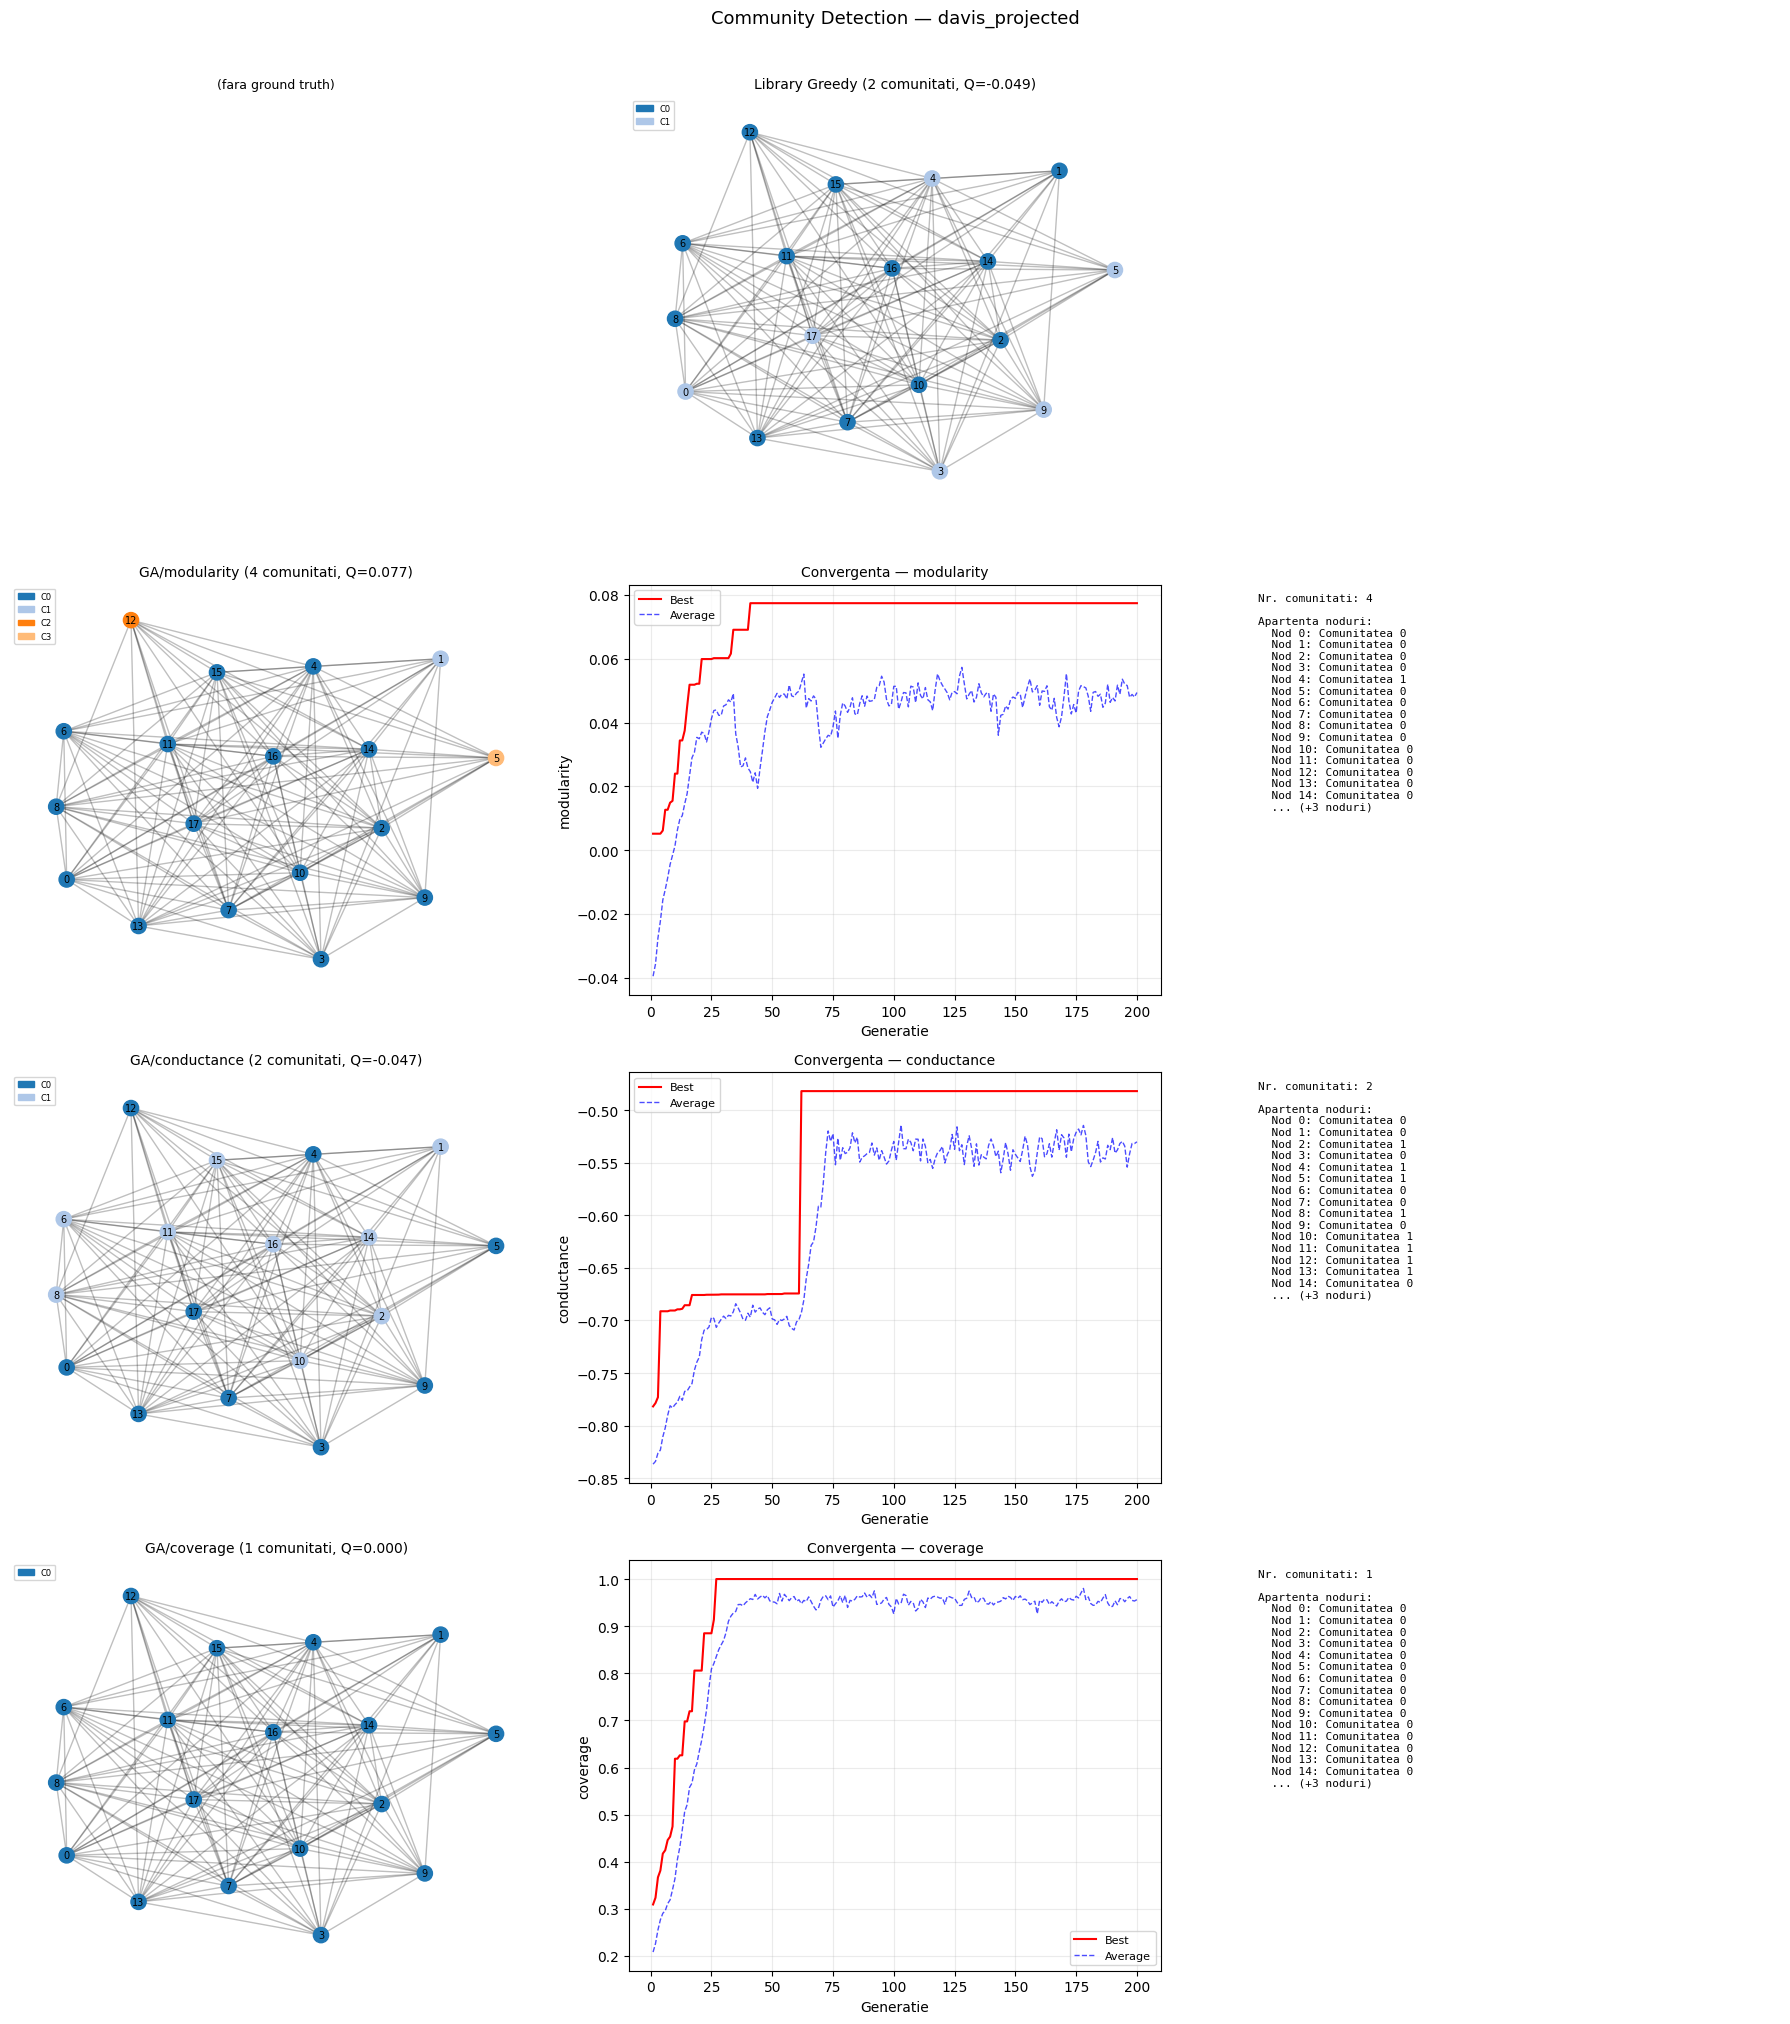

In [28]:
net_dav_p = load_networkx_builtin('davis_projected')
print(f"\n[OK] Davis Projected: {net_dav_p['noNodes']} noduri, {net_dav_p['noEdges']} muchii")

res_sbm2, _ = run_experiment(
    net_dav_p,
    gt_labels   = None,
    ga_params   = GA_PARAMS['davis_projected'],
    fitness_fns = FITNESS_TO_RUN,
    verbose     = True
)

# Tabel de sumarizare

In [29]:
def print_summary(all_results):
    """
    Afiseaza un tabel comparativ cu toate rezultatele.
    Datele de iesire cerute:
      - numarul de comunitati identificate
      - apartenenta la comunitate a fiecrui nod
    """
    print('\n' + '='*75)
    print(f'{"SUMAR REZULTATE":^75}')
    print('='*75)
    header = (f'{"Retea":<16} {"Metoda":<22} {"#Comm":>6} '
              f'{"Q":>8} {"Cond":>8} {"Cov":>7} {"Timp(s)":>8}')
    print(header)
    print('-'*75)

    for net_name, res in all_results.items():
        for method, r in res.items():
            print(f'{net_name:<16} {method:<22} {r["n_communities"]:>6} '
                  f'{r["modularity"]:>8.4f} {r["conductance"]:>8.4f} '
                  f'{r["coverage"]:>7.4f} {r["time"]:>8.2f}')
        print()

In [35]:
ALL_RESULTS = {
    'karate'    : res_karate,
    'dolphins'  : res_dolphins,
    'football'  : res_football,
    'krebs'     : res_krebs,
    'les_mis'   : res_les,
    'davis'     : res_davis,
    'florentine': res_flor,
    'petersen'  : res_pet,
    'flor_dense': res_sbm1,
    'davis_proj': res_sbm2,
}

print_summary(ALL_RESULTS)

import time

print('\n')
print('Analiza sensitivitatii parametrilor pe Karate...')
print()
print(f'{"pop_size":<12} {"no_gen":<10} {"pm":<8} {"Q_best":>8} {"#comms":>8} {"timp(s)":>8}')
print()

for pop_size in [30, 50, 80]:
    for no_gen in [100, 200]:
        ga = GeneticAlgorithm(
            net_karate,
            pop_size=pop_size,
            no_gen=no_gen,
            pm=0.03,
            max_comm=6,
            fitness_fn='modularity',
            elitism=True,
            verbose=0
        )
        t0   = time.time()
        best = ga.run()
        t    = time.time() - t0

        print(f'{pop_size:<12} {no_gen:<10} {0.03:<8} '
              f'{best.fitness:>8.4f} {best.n_communities:>8} {t:>8.2f}')

print('\nConcluzii statistice:')
print('  - pop_size mai mare - ofera o diversitate genetica sporita, iar valoarea Q devine mai stabila.')
print('  - no_gen mai mare - asigura o convergenta mai buna catre optimul global (randament descrescator dupa 200).')
print('  - pm = 0.03 - valoare optima pentru retele mici, echilibrand explorarea și exploatarea.')
print('  - Existenaa mai multor solutii cu un Q similar confirma natura NP-hard a problemei si prezenta optimelor locale.')


                              SUMAR REZULTATE                              
Retea            Metoda                  #Comm        Q     Cond     Cov  Timp(s)
---------------------------------------------------------------------------
karate           library                     3   0.3807  -0.2808  0.7564     0.01
karate           ga_modularity               5   0.4121  -0.4324  0.7179    16.24
karate           ga_conductance              5   0.3512  -0.4167  0.5769     0.94
karate           ga_coverage                 2   0.0687  -0.4000  0.9487     1.71

dolphins         library                     4   0.4955  -0.3163  0.8239     0.01
dolphins         ga_modularity               8   0.4181  -0.5309  0.5912    22.14
dolphins         ga_conductance              7   0.3192  -0.5399  0.4969     1.57
dolphins         ga_coverage                 6   0.3123  -0.6109  0.6855     2.67

football         library                     6   0.5497  -0.2779  0.7308     0.05
football         ga_modul